# 05 Time heterogeneity models

This notebook reuses the 04 model pipeline, splits the sample into three selected four-hour local-time windows, removes time-window predictors from X, runs one OLS model per selected window, and exports side-by-side coefficient comparison tables.


In [1]:
# =========================================================
# 0. Imports and model control panel
#    Python 3.8 compatible
# =========================================================
import json
import math
import os
import re
import warnings
from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---------------------------------------------------------
# Target
# ---------------------------------------------------------
Y_COL = "speed_kmh"
# Other common targets:
# Y_COL = "duration"
# Y_COL = "final_distance_m"
# Y_COL = "overspeed_20"
# Y_COL = "speed_kmh_minus_service_time"

# raw, log, log1p, sqrt, signed_log1p
# Y_TRANSFORM = "log1p"
Y_TRANSFORM = "raw"
ROW_QUERY = None

# ---------------------------------------------------------
# Model run controls
# ---------------------------------------------------------
# If RUN_MULTIPLE_MODEL_SPECS is True, MODEL_RUN_SPECS controls all row filters.
# Each key becomes a separate output folder under BASE_OUTPUT_ROOT.
RUN_MULTIPLE_MODEL_SPECS = True
PRIMARY_RUN_NAME = "h02_06"

# Three selected four-hour local-time windows. Each run uses the same covariates,
# excluding time-window indicators, so coefficients are comparable across time blocks.
TIME_HETEROGENEITY_WINDOWS = OrderedDict([
    ("h02_06", {"label": "02:00-06:00", "hour_start": 2, "hour_end": 6}),
    ("h10_14", {"label": "10:00-14:00", "hour_start": 10, "hour_end": 14}),
    ("h16_20", {"label": "16:00-20:00", "hour_start": 16, "hour_end": 20}),
])

BASE_ROW_QUERY_FOR_TIME_HETEROGENEITY = "speed_kmh <= 40"

MODEL_RUN_SPECS = OrderedDict([
    (
        run_name,
        "%s and start_hour_local >= %d and start_hour_local < %d" % (
            BASE_ROW_QUERY_FOR_TIME_HETEROGENEITY,
            info["hour_start"],
            info["hour_end"],
        ),
    )
    for run_name, info in TIME_HETEROGENEITY_WINDOWS.items()
])

# Keep expensive diagnostics focused by default. Turn these on when you need every run fully audited.
RUN_DISTRIBUTION_DASHBOARD_FOR_ALL_SPECS = False
RUN_R2_DIAGNOSTICS = True
RUN_R2_DIAGNOSTICS_FOR_ALL_SPECS = False
RUN_XGBOOST_SHAP_FOR_ALL_SPECS = False

# Optional cluster robust standard errors.
CLUSTER_COL = "courier_id"

# ---------------------------------------------------------
# Variable whitelist
# ---------------------------------------------------------
# Only variables listed here, plus X_EXTRA, can enter the model.
# If a listed variable is absent, it is reported in missing_whitelist_variables.csv.

GRAPHML_ROAD_CLASS_SHARE_COLS = [
    "road_class_share_levelFourRoad_lenw_mean",
    "road_class_share_levelThreeRoad_lenw_mean",
    "road_class_share_secondaryRoad_lenw_mean",
    "road_class_share_nationalRoad_lenw_mean",
    "road_class_share_provincialRoad_lenw_mean",
    # "road_class_share_overPass_lenw_mean",
    # "road_class_share_underPass_lenw_mean",
]

ROAD_TOPOLOGY_GEOMETRY_COLS = [
    "curvature_deg_per_m_lenw_mean",
    "intersection_density_per_km_300m_lenw_mean",
    # "degree_z_mean_end_lenw_mean",
    "betweenness_log1p_z_mean_end_lenw_mean",
    "closeness_per_km_z_mean_end_lenw_mean",
]

POI_LANDUSE_COLS = [
    # "restaurant_shp_count_30m_lenw_mean",
    "poi_count_30m_lenw_mean",
    "poi_mix_entropy_norm_30m_lenw_mean",
    # "poi_count_restaurant_30m_lenw_mean",
]

TIME_WINDOW_COLS = [
    "time_midday_peak_10_14",
    "time_evening_peak_16_20",
    "time_midnight_2_6",
]

# In this notebook, each model is estimated inside one time block.
# Time-window indicators are still created for consistency with 04,
# but they are excluded from X because they are constants within each split.
TIME_WINDOW_COLS_FOR_TIME_HETEROGENEITY_X = []

X_GROUPS = OrderedDict([
    ("trip_state", [
        # "duration",
        "onhand_order_count_start",
        "time_pressure_min",
        "time_pressure_late",
        "is_weekend_local",
        # "final_distance_m",
        # "start_hour_sin",
        # "start_hour_cos",
    ]),
    # Time-window indicators are excluded because each model is run inside a time block.
    ("time_window", TIME_WINDOW_COLS_FOR_TIME_HETEROGENEITY_X),
    ("rider_behavior", [
        "rider_avg_orders_per_active_day",
        "full_time",
        # "rider_active_day_share_in_data",
        # "rider_median_onhand_raw",
        # "rider_median_max_onhand_per_wave",
        # "rider_share_batch_wave_ge2",
        # "rider_median_segment_distance_m",
        "rider_mean_segment_distance_m",
    ]),
    ("road_class_shares", GRAPHML_ROAD_CLASS_SHARE_COLS),
    ("road_topology_geometry", ROAD_TOPOLOGY_GEOMETRY_COLS),
    ("landuse", POI_LANDUSE_COLS),
])

# Add variables without editing the groups above.
# Derived numeric variables can also enter here once declared in DERIVED_VARIABLE_SPECS.
X_EXTRA = [
    # "time_pressure_urgent",
    # "time_pressure_late",
    # "time_pressure_tight",
]

# ---------------------------------------------------------
# Derived variable controls
# ---------------------------------------------------------
# These are created before the whitelist and categorical controls are applied.
DERIVED_VARIABLE_SPECS = OrderedDict([
    # ("time_pressure_bucket", {
    #     "type": "cut",
    #     "source": "time_pressure_min",
    #     "bins": [-np.inf, 0, 5, 15, 30, np.inf],
    #     "labels": ["lt0", "0_5", "5_15", "15_30", "ge30"],
    #     "categorical": True,
    # }),
    # ("time_pressure_urgent", {
    #     "type": "indicator",
    #     "condition": "time_pressure_min < 5",
    #     "categorical": False,
    # }),
    ("time_pressure_late", {
        "type": "indicator",
        "condition": "time_pressure_min < 0",
        "categorical": False,
    }),
    # ("time_pressure_tight", {
    #     "type": "indicator",
    #     "condition": "(time_pressure_min >= 0) & (time_pressure_min < 5)",
    #     "categorical": False,
    # }),

    # -----------------------------------------------------
    # Time-window indicators
    # Baseline group is all other hours, where all three indicators equal 0.
    # Intervals are left-closed and right-open:
    # 10 <= hour < 14, 16 <= hour < 20, 2 <= hour < 6.
    # -----------------------------------------------------
    ("time_midday_peak_10_14", {
        "type": "indicator",
        "condition": "(start_hour_local >= 10) & (start_hour_local < 14)",
        "categorical": False,
    }),
    ("time_evening_peak_16_20", {
        "type": "indicator",
        "condition": "(start_hour_local >= 16) & (start_hour_local < 20)",
        "categorical": False,
    }),
    ("time_midnight_2_6", {
        "type": "indicator",
        "condition": "(start_hour_local >= 2) & (start_hour_local < 6)",
        "categorical": False,
    }),

    # ------------------------------------------------------
    # Rider activity indicators
    # ------------------------------------------------
    ("full_time", {
        "type": "indicator",
        "condition": "(rider_active_day_share_in_data == 1)",
        "categorical": False,
    }),
])

# Remove variables after whitelist selection.
X_DROP = []

# Categorical controls are dummy-encoded with drop_first=True.
# Add columns only when they exist in your model table.
CATEGORICAL_VARS = [
    # Main action-context controls. segment_task_orientation uses parent_end_action
    # to infer the target for FETCH -> GRAB and DELIVER -> GRAB rows.
    "segment_task_orientation",
    # "segment_grab_context",
    # Robustness option:
    # "action_pair",
    # "time_pressure_bucket",
    # "start_hour_local",
]

# ---------------------------------------------------------
# Interaction controls
# ---------------------------------------------------------
# Interactions are created after continuous transforms and before the design matrix.
# Categorical left variables are expanded with drop_first=True, matching build_design_matrix.
ADD_INTERACTIONS = False
INTERACTION_SPECS = [
    # {
    #     "name": "action_pair_x_topology",
    #     "left": ["action_pair"],
    #     "right": ROAD_TOPOLOGY_GEOMETRY_COLS,
    # },
]

# Speed is mechanically distance divided by duration. Turn this on for a more behavioral speed model.
DROP_MECHANICAL_X_WHEN_Y_IS_SPEED = False
MECHANICAL_X_WHEN_Y_SPEED = [
    # "duration",
    # "final_distance_m",
    # "straight_distance_m",
    # "dist_network_only",
]

# Road-class shares sum to one when all classes are included, so one reference class is dropped when an intercept is used.
DROP_ONE_ROAD_CLASS_REFERENCE = True
ROAD_CLASS_REFERENCE_PREFERENCE = ["road_class_share_levelFourRoad_lenw_mean"]
ROAD_CLASS_REFERENCE_MODE = "preference_then_largest"  # preference_then_largest, auto_largest, auto_smallest

# These variables are never allowed in X.
PROTECTED_NON_X_BASE = [
    "overspeed_20",
    "speed_kmh",
    "speed_kmh_minus_service_time",
    "travel_time_minus_service_sec",
    "final_distance_m",
    "path_len_m_from_edges",
    "dist_network_only",
    "start_time",
    "end_time",
    "parent_final_distance_m",
    "parent_duration",
]

# ---------------------------------------------------------
# Transformation controls
# ---------------------------------------------------------
# Transform rules for continuous X variables.
#
# Supported single rules:
#   raw
#   log
#   log1p
#   sqrt
#   signed_log1p
#   logit01
#   standardize
#   div:<number>      example: "div:1000"
#   mul:<number>      example: "mul:60"
#   add:<number>      example: "add:1"
#
# Supported chained rules with "|":
#   "div:1000|log1p"
#   "log1p|standardize"
#
# Put only numeric variables here.
VARIABLE_TRANSFORMS = OrderedDict([
    # ("duration", "log1p"),
    # ("poi_count_restaurant_300m_lenw_mean", "log1p"),
    ("poi_count_30m_lenw_mean", "log1p"),
    # ("speed_kmh", "div:0.7"),
    # ("rider_avg_orders_per_active_day", "log1p"),
    # ("curvature_deg_per_m_lenw_mean", "mul:1000"),
    # ("betweenness_raw_mean_end_lenw_mean", "div:10000|log1p"),
    ("restaurant_shp_count_30m_lenw_mean", "log1p"),    
    ("rider_mean_segment_distance_m", "div:1000"),
    # ("road_len_in_300m_lenw_mean", "log1p"),
    # ("intersection_density_per_km_300m_lenw_mean", "log1p"),
])

PATTERN_VARIABLE_TRANSFORMS = OrderedDict([
    # (r"road_class_", "log1p"),
    # (r"_mean", "log1p"),
    # (r"_count_", "log1p"),
])

AUTO_APPLY_RECOMMENDED_TRANSFORMS = False
RECOMMEND_SKEW_THRESHOLD = 1.0
RECOMMEND_MIN_UNIQUE = 20

# If exact collinearity occurs, columns earlier in this list are kept first.
# This prevents a variable such as restaurant count from being dropped just because an equivalent column appears earlier.
ALIAS_KEEP_PREFERENCE_RAW = [
    "poi_count_restaurant_30m_lenw_mean",
    "restaurant_shp_count_30m_lenw_mean",
]

# VIF controls. VIF is computed with an intercept using auxiliary regressions.
# AUTO_DROP_HIGH_VIF remains off by default to avoid silent model changes.
AUTO_DROP_HIGH_VIF = False
VIF_THRESHOLD = 10.0
VIF_PROTECTED = ["const"]
VIF_MAX_ROWS = 100000
VIF_DRIVER_MAX_ROWS = 100000

# OLS options.
RUN_OLS = True
OLS_STANDARDIZE_X_FOR_ESTIMATION = False
SAVE_DIAGNOSTIC_PLOTS = True
PLOT_SAMPLE_N = 80000

# Distribution dashboard options.
RUN_VARIABLE_DISTRIBUTION_DASHBOARD = True
MAX_DISTRIBUTION_PLOT_VARS = 80
DISTRIBUTION_PLOT_SAMPLE_N = 100000
DISTRIBUTION_HIST_BINS = 60

# XGBoost and SHAP options.
RUN_XGBOOST_SHAP = True
XGB_TEST_SIZE = 0.20
XGB_MAX_ROWS = 250000
SHAP_SAMPLE_N = 20000
SHAP_TOP_N = 20
XGB_PARAMS = {
    "n_estimators": 500,
    "max_depth": 4,
    "learning_rate": 0.04,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_lambda": 1.0,
    "min_child_weight": 5,
    "objective": "reg:squarederror",
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
}


In [2]:
# =========================================================
# 1. Paths and output structure
# =========================================================
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

SEARCH_DIRS = [
    BASE_DIR,
    BASE_DIR.parent,
    Path.cwd(),
    Path("/mnt/data"),
]

PIPELINE_ROOT = BASE_DIR / "outputs_pipeline_aligned"
MANIFEST_PATH = PIPELINE_ROOT / "pipeline_manifest.json"
PIPELINE_MANIFEST = json.loads(MANIFEST_PATH.read_text(encoding="utf-8")) if MANIFEST_PATH.exists() else {}
BASE_OUTPUT_ROOT = Path(PIPELINE_MANIFEST.get("time_heterogeneity_root", PIPELINE_ROOT / "05_time_heterogeneity_models"))
OUTPUT_ROOT = BASE_OUTPUT_ROOT
FULL_PRECISION_DIR = OUTPUT_ROOT / "full_precision"
ROUNDED_DIR = OUTPUT_ROOT / "rounded"
DIAGNOSTICS_DIR = OUTPUT_ROOT / "diagnostics"
PLOTS_DIR = OUTPUT_ROOT / "plots"


def set_output_dirs_for_run(run_name=None):
    """Set global output directories.

    Important behavior:
    - With run_name=None, only BASE_OUTPUT_ROOT is created.
    - Per-run folders such as full_precision, rounded, diagnostics, and plots are
      created only inside an actual run folder.
    This avoids empty root-level folders under 05_time_heterogeneity_models.
    """
    global OUTPUT_ROOT, FULL_PRECISION_DIR, ROUNDED_DIR, DIAGNOSTICS_DIR, PLOTS_DIR

    if run_name is None or str(run_name).strip() == "":
        OUTPUT_ROOT = BASE_OUTPUT_ROOT
        BASE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
        FULL_PRECISION_DIR = OUTPUT_ROOT / "full_precision"
        ROUNDED_DIR = OUTPUT_ROOT / "rounded"
        DIAGNOSTICS_DIR = OUTPUT_ROOT / "diagnostics"
        PLOTS_DIR = OUTPUT_ROOT / "plots"
        return OUTPUT_ROOT

    safe_run_name = re.sub(r"[^A-Za-z0-9_]+", "_", str(run_name)).strip("_")
    OUTPUT_ROOT = BASE_OUTPUT_ROOT / safe_run_name
    FULL_PRECISION_DIR = OUTPUT_ROOT / "full_precision"
    ROUNDED_DIR = OUTPUT_ROOT / "rounded"
    DIAGNOSTICS_DIR = OUTPUT_ROOT / "diagnostics"
    PLOTS_DIR = OUTPUT_ROOT / "plots"

    for _p in [OUTPUT_ROOT, FULL_PRECISION_DIR, ROUNDED_DIR, DIAGNOSTICS_DIR, PLOTS_DIR]:
        _p.mkdir(parents=True, exist_ok=True)

    return OUTPUT_ROOT

set_output_dirs_for_run(None)

# Clean empty legacy root-level folders that may have been created by older versions.
# Non-empty folders are left untouched.
def cleanup_empty_root_output_subdirs():
    for _name in ["full_precision", "rounded", "diagnostics", "plots"]:
        _p = BASE_OUTPUT_ROOT / _name
        try:
            if _p.exists() and _p.is_dir() and len(list(_p.iterdir())) == 0:
                _p.rmdir()
                print("Removed empty legacy root folder:", _p)
        except Exception as exc:
            print("Could not remove legacy root folder %s: %s" % (_p, exc))

cleanup_empty_root_output_subdirs()

TRIP_TABLE_CANDIDATES = [
    Path(PIPELINE_MANIFEST.get("segment_model_csv_gz", PIPELINE_ROOT / "02_variables" / "segments" / "segment_model_table.csv.gz")),
    PIPELINE_ROOT / "02_variables" / "segments" / "segment_model_table.csv",
]


def resolve_path(candidates, search_dirs=None, required=True):
    if search_dirs is None:
        search_dirs = SEARCH_DIRS
    if isinstance(candidates, (str, Path)):
        candidates = [candidates]
    checked = []
    for cand in candidates:
        p = Path(cand)
        if p.is_absolute():
            checked.append(str(p))
            if p.exists():
                return p
    for root in search_dirs:
        root = Path(root)
        for cand in candidates:
            p = root / cand
            checked.append(str(p))
            if p.exists():
                return p
    if required:
        raise FileNotFoundError("No input found. Checked:\n%s" % "\n".join(checked))
    return Path(candidates[0])

TRIP_TABLE_PATH = resolve_path(TRIP_TABLE_CANDIDATES, required=True)
print("Using model table:", TRIP_TABLE_PATH)
print("Base output root:", BASE_OUTPUT_ROOT)


Using model table: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\02_variables\segments\segment_model_table.csv.gz
Base output root: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\05_time_heterogeneity_models


In [3]:
# =========================================================
# 2. General helper functions
# =========================================================
def ensure_dir(path_like):
    Path(path_like).mkdir(parents=True, exist_ok=True)


def save_json(obj, path):
    path = Path(path)
    ensure_dir(path.parent)
    path.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding="utf-8")


def save_text(text, path):
    path = Path(path)
    ensure_dir(path.parent)
    path.write_text(str(text), encoding="utf-8")


def read_table(path):
    path = Path(path)
    if path.suffix == ".gz":
        return pd.read_csv(path, compression="gzip")
    return pd.read_csv(path)


def write_csv_atomic(df, path, **kwargs):
    path = Path(path)
    ensure_dir(path.parent)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(tmp, **kwargs)
    os.replace(str(tmp), str(path))


def round_numeric_columns(df, digits=3):
    out = df.copy()
    for col in out.columns:
        s = out[col]
        if pd.api.types.is_bool_dtype(s):
            continue
        if pd.api.types.is_numeric_dtype(s):
            out[col] = pd.to_numeric(s, errors="coerce").round(digits)
    return out


def write_result_table(df, relative_path, index=False, rounded=True, digits=3):
    """Save full precision and optional rounded copy in separated folders."""
    rel = Path(relative_path)
    full_path = FULL_PRECISION_DIR / rel
    write_csv_atomic(df, full_path, index=index)
    if rounded:
        rounded_path = ROUNDED_DIR / rel
        write_csv_atomic(round_numeric_columns(df, digits=digits), rounded_path, index=index)
    return full_path


def make_unique_column_names(cols):
    seen = {}
    out = []
    for c in list(cols):
        c = str(c)
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append("%s__dup%d" % (c, seen[c]))
    return out


def pick_existing(df, cols):
    return [c for c in cols if c in df.columns]


def is_road_class_share_col(c):
    return re.match(r"^road_class_share_.+_lenw_mean$", str(c)) is not None


def clean_text(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s in {"", "nan", "None", "<NA>", "[]"}:
        return ""
    return s


def choose_road_class_reference(df, road_cols):
    road_cols = [c for c in road_cols if c in df.columns]
    if len(road_cols) <= 1:
        return None
    if ROAD_CLASS_REFERENCE_MODE == "preference_then_largest":
        for c in ROAD_CLASS_REFERENCE_PREFERENCE:
            if c in road_cols:
                return c
    means = df[road_cols].apply(pd.to_numeric, errors="coerce").mean().sort_values(ascending=False)
    if ROAD_CLASS_REFERENCE_MODE == "auto_smallest":
        means = means.sort_values(ascending=True)
    if len(means) == 0:
        return road_cols[-1]
    return str(means.index[0])


def transform_rule_for_variable(var, manual_rules):
    if var in manual_rules:
        return manual_rules.get(var, "raw")
    for pat, rule in PATTERN_VARIABLE_TRANSFORMS.items():
        if re.search(pat, str(var)):
            return rule
    return "raw"


def drop_constant_columns(df):
    keep = []
    dropped = []
    for c in df.columns:
        nun = df[c].nunique(dropna=True)
        if nun <= 1:
            dropped.append(c)
        else:
            keep.append(c)
    return df[keep].copy(), dropped


def numeric_summary_table(df, cols, y_col=None):
    rows = []
    for c in cols:
        if c not in df.columns:
            continue
        s = pd.to_numeric(df[c], errors="coerce")
        non = s.replace([np.inf, -np.inf], np.nan).dropna()
        if len(non) == 0:
            rows.append({
                "variable": c,
                "role": "y" if c == y_col else "x",
                "n": 0,
                "missing": int(len(df)),
                "missing_share": 1.0,
                "n_unique": 0,
                "mean": np.nan,
                "std": np.nan,
                "min": np.nan,
                "p01": np.nan,
                "p05": np.nan,
                "p25": np.nan,
                "p50": np.nan,
                "p75": np.nan,
                "p95": np.nan,
                "p99": np.nan,
                "max": np.nan,
                "share_zero": np.nan,
                "skew": np.nan,
                "kurtosis": np.nan,
                "corr_with_y": np.nan,
            })
            continue
        corr_with_y = np.nan
        if y_col is not None and c != y_col and y_col in df.columns:
            yy = pd.to_numeric(df[y_col], errors="coerce")
            tmp = pd.DataFrame({"x": s, "y": yy}).replace([np.inf, -np.inf], np.nan).dropna()
            if len(tmp) > 2 and tmp["x"].nunique() > 1 and tmp["y"].nunique() > 1:
                corr_with_y = float(tmp["x"].corr(tmp["y"]))
        rows.append({
            "variable": c,
            "role": "y" if c == y_col else "x",
            "n": int(non.shape[0]),
            "missing": int(s.isna().sum()),
            "missing_share": float(s.isna().mean()),
            "n_unique": int(non.nunique(dropna=True)),
            "mean": float(non.mean()),
            "std": float(non.std(ddof=0)),
            "min": float(non.min()),
            "p01": float(non.quantile(0.01)),
            "p05": float(non.quantile(0.05)),
            "p25": float(non.quantile(0.25)),
            "p50": float(non.quantile(0.50)),
            "p75": float(non.quantile(0.75)),
            "p95": float(non.quantile(0.95)),
            "p99": float(non.quantile(0.99)),
            "max": float(non.max()),
            "share_zero": float((non == 0).mean()),
            "skew": float(non.skew()) if non.nunique() > 2 else np.nan,
            "kurtosis": float(non.kurtosis()) if non.nunique() > 2 else np.nan,
            "corr_with_y": corr_with_y,
        })
    return pd.DataFrame(rows)


In [4]:
# =========================================================
# 3. Transformation and design-matrix helpers
# =========================================================
def _number_label(x):
    v = float(x)
    s = "%g" % v
    s = s.replace("-", "m").replace(".", "p")
    return s


def _transform_one_rule(s, rule):
    rule = str(rule or "raw").strip().lower()

    if rule == "raw":
        return s, "raw"

    if rule.startswith("div:"):
        denom = float(rule.split(":", 1)[1])
        if denom == 0:
            raise ValueError("div transform has zero denominator")
        return s / denom, "div:%g" % denom

    if rule.startswith("mul:"):
        factor = float(rule.split(":", 1)[1])
        return s * factor, "mul:%g" % factor

    if rule.startswith("add:"):
        offset = float(rule.split(":", 1)[1])
        return s + offset, "add:%g" % offset

    if rule == "log":
        out = pd.Series(np.nan, index=s.index, dtype=float)
        mask = s > 0
        out.loc[mask] = np.log(s.loc[mask])
        return out, "log_positive_only"

    if rule == "log1p":
        out = pd.Series(np.nan, index=s.index, dtype=float)
        mask = s >= 0
        out.loc[mask] = np.log1p(s.loc[mask])
        return out, "log1p_nonnegative_only"

    if rule == "sqrt":
        out = pd.Series(np.nan, index=s.index, dtype=float)
        mask = s >= 0
        out.loc[mask] = np.sqrt(s.loc[mask])
        return out, "sqrt_nonnegative_only"

    if rule == "signed_log1p":
        return np.sign(s) * np.log1p(np.abs(s)), "signed_log1p"

    if rule == "logit01":
        eps = 1e-6
        out = pd.Series(np.nan, index=s.index, dtype=float)
        mask = (s >= 0) & (s <= 1)
        v = s.loc[mask].clip(eps, 1.0 - eps)
        out.loc[mask] = np.log(v / (1.0 - v))
        return out, "logit01_clipped"

    if rule == "standardize":
        mu = s.mean()
        sd = s.std(ddof=0)
        if pd.isna(sd) or sd <= 0:
            return s * np.nan, "standardize_failed"
        return (s - mu) / sd, "standardize"

    raise ValueError("Unknown transform rule: %s" % rule)


def transform_series(s, rule):
    s = pd.to_numeric(s, errors="coerce")
    rules = [r.strip().lower() for r in str(rule or "raw").split("|") if r.strip()]
    if len(rules) == 0:
        rules = ["raw"]

    out = s
    statuses = []
    for one_rule in rules:
        out, status = _transform_one_rule(out, one_rule)
        statuses.append(status)

    return out, "|".join(statuses)


def _rule_prefix(rule):
    rule = str(rule or "raw").strip().lower()

    simple_prefixes = {
        "raw": "",
        "log": "ln_",
        "log1p": "ln1p_",
        "sqrt": "sqrt_",
        "signed_log1p": "slog1p_",
        "logit01": "logit_",
        "standardize": "z_",
    }

    if rule in simple_prefixes:
        return simple_prefixes[rule]

    if rule.startswith("div:"):
        return "div%s_" % _number_label(rule.split(":", 1)[1])

    if rule.startswith("mul:"):
        return "mul%s_" % _number_label(rule.split(":", 1)[1])

    if rule.startswith("add:"):
        return "add%s_" % _number_label(rule.split(":", 1)[1])

    return re.sub(r"[^A-Za-z0-9]+", "_", rule).strip("_") + "_"


def transformed_name(var, rule):
    rule = str(rule or "raw").strip().lower()
    if rule == "raw":
        return var

    rules = [r.strip().lower() for r in rule.split("|") if r.strip()]
    prefix = "".join([_rule_prefix(r) for r in rules])
    return prefix + var


def recommend_transform_for_series(series):
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) == 0:
        return "raw", "all_missing"
    nun = int(s.nunique(dropna=True))
    mn = float(s.min())
    if nun <= 2:
        return "raw", "binary_or_constant"
    if nun < RECOMMEND_MIN_UNIQUE:
        return "raw", "low_cardinality"
    skew = float(s.skew()) if nun > 2 else 0.0
    if mn >= 0 and abs(skew) >= RECOMMEND_SKEW_THRESHOLD:
        if mn == 0:
            return "log1p", "nonnegative_with_zero_and_high_skew"
        return "log", "positive_and_high_skew"
    if mn < 0 and abs(skew) >= RECOMMEND_SKEW_THRESHOLD:
        return "signed_log1p", "has_negative_values_and_high_skew"
    return "raw", "no_strong_transform_signal"


def build_transform_audit(df, variables, manual_rules):
    rows = []
    for c in variables:
        if c not in df.columns:
            continue
        rec, reason = recommend_transform_for_series(df[c])
        manual = transform_rule_for_variable(c, manual_rules)
        final = manual
        if AUTO_APPLY_RECOMMENDED_TRANSFORMS and manual == "raw":
            final = rec
        rows.append({
            "variable": c,
            "manual_rule": manual,
            "recommended_rule": rec,
            "recommend_reason": reason,
            "final_rule_if_applied": final,
        })
    return pd.DataFrame(rows)


def apply_transform_rules(df, variables, manual_rules, transform_audit=None):
    out = df.copy()
    rows = []
    final_rules = {}
    audit_map = {}
    if transform_audit is not None and len(transform_audit) > 0:
        for r in transform_audit.itertuples(index=False):
            audit_map[getattr(r, "variable")] = getattr(r, "final_rule_if_applied")
    for c in variables:
        if c not in out.columns:
            continue
        rule = transform_rule_for_variable(c, manual_rules)
        if AUTO_APPLY_RECOMMENDED_TRANSFORMS and c in audit_map and rule == "raw":
            rule = audit_map[c]
        final_rules[c] = rule
        new_c = transformed_name(c, rule)
        if rule == "raw":
            rows.append({
                "variable": c,
                "new_variable": c,
                "rule": "raw",
                "status": "kept_raw",
                "n_missing_after": int(out[c].isna().sum()),
            })
            continue
        try:
            transformed, status = transform_series(out[c], rule)
            out[new_c] = transformed
            rows.append({
                "variable": c,
                "new_variable": new_c,
                "rule": rule,
                "status": status,
                "n_missing_after": int(pd.isna(transformed).sum()),
            })
        except Exception as exc:
            rows.append({
                "variable": c,
                "new_variable": c,
                "rule": rule,
                "status": "failed_%s" % repr(exc),
                "n_missing_after": int(out[c].isna().sum()),
            })
            final_rules[c] = "raw"
    return out, final_rules, pd.DataFrame(rows)


def replace_with_transformed_names(cols, rules):
    out = []
    for c in cols:
        rule = rules.get(c, "raw")
        out.append(transformed_name(c, rule))
    return out


def model_var_for_raw(raw, rules):
    return transformed_name(raw, rules.get(raw, "raw"))


def alias_keep_model_names(rules):
    out = []
    for raw in ALIAS_KEEP_PREFERENCE_RAW:
        out.append(model_var_for_raw(raw, rules))
    return out


def reorder_for_alias_preference(cols, preferred):
    preferred = [c for c in preferred if c in cols]
    rest = [c for c in cols if c not in set(preferred)]
    return preferred + rest


def build_design_matrix(df, cont_cols, cat_cols=None, add_const=True, preferred_order=None):
    cat_cols = cat_cols or []
    preferred_order = preferred_order or []
    cont_cols = reorder_for_alias_preference(list(cont_cols), preferred_order)
    parts = []
    if len(cont_cols) > 0:
        cont_df = df[cont_cols].apply(pd.to_numeric, errors="coerce")
        if cont_df.columns.duplicated().any():
            cont_df.columns = make_unique_column_names(cont_df.columns)
        parts.append(cont_df)
    for c in cat_cols:
        if c not in df.columns:
            continue
        tmp = df[c]
        if pd.api.types.is_numeric_dtype(tmp):
            tmp = tmp.astype("Int64").astype(str)
        else:
            tmp = tmp.astype(str)
        dummies = pd.get_dummies(tmp, prefix=c, drop_first=True)
        if dummies.columns.duplicated().any():
            dummies.columns = make_unique_column_names(dummies.columns)
        parts.append(dummies)
    if len(parts) == 0:
        X = pd.DataFrame(index=df.index)
    else:
        X = pd.concat(parts, axis=1)
    X = X.apply(pd.to_numeric, errors="coerce")
    X, dropped_const = drop_constant_columns(X)
    if add_const:
        X = sm.add_constant(X, has_constant="add")
    return X, dropped_const


def drop_exact_alias_columns(X, protect_cols=None, tol=1e-12):
    protect_cols = protect_cols or []
    ordered_cols = [c for c in X.columns if c in protect_cols] + [c for c in X.columns if c not in protect_cols]
    X = X[ordered_cols].copy()
    if X.shape[1] <= 1:
        return X, []
    vals = X.to_numpy(dtype=float)
    keep_idx = []
    dropped = []
    current_rank = 0
    for j, c in enumerate(X.columns):
        sub_idx = keep_idx + [j]
        sub_vals = vals[:, sub_idx]
        try:
            rank = int(np.linalg.matrix_rank(sub_vals, tol=tol))
        except Exception:
            rank = current_rank
        if rank > current_rank:
            keep_idx.append(j)
            current_rank = rank
        else:
            dropped.append(c)
    keep_cols = list(X.columns[keep_idx])
    return X[keep_cols].copy(), dropped


def prepare_vif_matrix(X, max_rows=None):
    """
    Prepare a numeric X matrix for VIF diagnostics.

    Important: this function does not remove the intercept before the
    auxiliary regressions. The intercept is included in each auxiliary
    regression to avoid uncentered VIF inflation for positive variables.
    """
    X_vif = X.copy()
    X_vif = X_vif.apply(pd.to_numeric, errors="coerce")
    X_vif = X_vif.replace([np.inf, -np.inf], np.nan)

    # VIF should use complete cases. This matches the actual OLS design
    # after rows with missing X have been removed.
    X_vif = X_vif.dropna(axis=0, how="any")

    if max_rows is not None and len(X_vif) > max_rows:
        X_vif = X_vif.sample(max_rows, random_state=RANDOM_SEED)

    # Drop constant non-intercept columns. Keep const if present.
    keep_cols = []
    dropped_constant = []
    for c in X_vif.columns:
        if c == "const":
            keep_cols.append(c)
            continue
        nun = X_vif[c].nunique(dropna=True)
        if nun <= 1:
            dropped_constant.append(c)
        else:
            keep_cols.append(c)

    X_vif = X_vif[keep_cols].copy()
    return X_vif, dropped_constant


def compute_vif(X, max_rows=None):
    """
    Correct VIF calculation with an intercept in each auxiliary regression.

    This implementation uses numpy least squares instead of statsmodels inside
    the loop, which is much faster once interactions create a wider model matrix.
    """
    X_vif, dropped_constant = prepare_vif_matrix(X, max_rows=max_rows)

    if "const" not in X_vif.columns:
        X_vif = sm.add_constant(X_vif, has_constant="add")

    variable_cols = [c for c in X_vif.columns if c != "const"]
    if len(variable_cols) == 0:
        return pd.DataFrame(columns=[
            "variable", "VIF", "aux_r2", "n_obs", "n_predictors_in_aux", "status"
        ])

    X_vif = X_vif.astype(float)
    rows = []
    for target in variable_cols:
        y_aux = X_vif[target].to_numpy(dtype=float)
        other_cols = [c for c in X_vif.columns if c != target]
        Z_aux = X_vif[other_cols].to_numpy(dtype=float)

        if Z_aux.shape[1] == 0:
            rows.append({
                "variable": target,
                "VIF": 1.0,
                "aux_r2": 0.0,
                "n_obs": int(len(X_vif)),
                "n_predictors_in_aux": 0,
                "status": "only_variable",
            })
            continue

        try:
            beta, residuals, rank, svals = np.linalg.lstsq(Z_aux, y_aux, rcond=None)
            fitted = Z_aux.dot(beta)
            resid = y_aux - fitted
            centered = y_aux - np.nanmean(y_aux)
            ss_total = float(np.dot(centered, centered))
            ss_resid = float(np.dot(resid, resid))
            if ss_total <= 0 or not np.isfinite(ss_total):
                aux_r2 = np.nan
                vif = np.nan
                status = "constant_target"
            else:
                aux_r2 = max(0.0, min(1.0, 1.0 - ss_resid / ss_total))
                if aux_r2 >= 1.0 - 1e-12:
                    vif = np.inf
                else:
                    vif = 1.0 / (1.0 - aux_r2)
                status = "ok" if rank == Z_aux.shape[1] else "ok_rank_deficient_aux"
        except Exception as exc:
            aux_r2 = np.nan
            vif = np.nan
            status = "failed: %s" % str(exc)

        rows.append({
            "variable": target,
            "VIF": float(vif) if pd.notna(vif) else np.nan,
            "aux_r2": aux_r2,
            "n_obs": int(len(X_vif)),
            "n_predictors_in_aux": int(max(0, Z_aux.shape[1] - 1)),
            "status": status,
        })

    vif_df = pd.DataFrame(rows)
    if len(dropped_constant) > 0:
        dropped_df = pd.DataFrame({
            "variable": dropped_constant,
            "VIF": np.nan,
            "aux_r2": np.nan,
            "n_obs": int(len(X_vif)),
            "n_predictors_in_aux": np.nan,
            "status": "dropped_constant_before_vif",
        })
        vif_df = pd.concat([vif_df, dropped_df], ignore_index=True)

    return vif_df.sort_values(["VIF", "variable"], ascending=[False, True]).reset_index(drop=True)


def iterative_drop_high_vif(X, threshold=10.0, protected=None):
    protected = set(protected or [])
    X_cur = X.copy()
    dropped = []

    while True:
        vif = compute_vif(X_cur)
        if vif.empty:
            break

        vif_ok = vif[vif["status"] == "ok"].copy()
        vif_ok = vif_ok[~vif_ok["variable"].isin(protected)].copy()
        if vif_ok.empty:
            break

        top = vif_ok.iloc[0]
        top_vif = float(top["VIF"])
        if np.isfinite(top_vif) and top_vif > threshold:
            col = top["variable"]
            if col in X_cur.columns:
                X_cur = X_cur.drop(columns=[col])
                dropped.append({
                    "variable": col,
                    "VIF_at_drop": top_vif,
                    "aux_r2_at_drop": float(top.get("aux_r2", np.nan)),
                })
                continue

        if not np.isfinite(top_vif):
            col = top["variable"]
            if col in X_cur.columns:
                X_cur = X_cur.drop(columns=[col])
                dropped.append({
                    "variable": col,
                    "VIF_at_drop": top_vif,
                    "aux_r2_at_drop": float(top.get("aux_r2", np.nan)),
                })
                continue

        break

    return X_cur, pd.DataFrame(dropped)


def vif_pairwise_correlations(X, threshold=0.60):
    X_vif, _ = prepare_vif_matrix(X)
    cols = [c for c in X_vif.columns if c != "const"]
    if len(cols) == 0:
        corr = pd.DataFrame()
        pairs = pd.DataFrame(columns=["var1", "var2", "corr", "abs_corr"])
        return corr, pairs

    corr = X_vif[cols].corr()
    rows = []
    for i, a in enumerate(cols):
        for b in cols[i + 1:]:
            val = corr.loc[a, b]
            if pd.notna(val) and abs(val) >= threshold:
                rows.append({
                    "var1": a,
                    "var2": b,
                    "corr": float(val),
                    "abs_corr": float(abs(val)),
                })
    pairs = pd.DataFrame(rows)
    if len(pairs) > 0:
        pairs = pairs.sort_values("abs_corr", ascending=False).reset_index(drop=True)
    else:
        pairs = pd.DataFrame(columns=["var1", "var2", "corr", "abs_corr"])
    return corr, pairs


def standardize_series_for_vif(s):
    s = pd.to_numeric(s, errors="coerce")
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return s * 0
    return (s - s.mean()) / sd


def _fast_aux_r2(y, Z):
    y_arr = np.asarray(y, dtype=float)
    Z_arr = np.asarray(Z, dtype=float)
    if Z_arr.ndim == 1:
        Z_arr = Z_arr.reshape(-1, 1)
    if Z_arr.shape[1] == 0:
        return np.nan
    try:
        beta, residuals, rank, svals = np.linalg.lstsq(Z_arr, y_arr, rcond=None)
        fitted = Z_arr.dot(beta)
        resid = y_arr - fitted
        centered = y_arr - np.nanmean(y_arr)
        ss_total = float(np.dot(centered, centered))
        ss_resid = float(np.dot(resid, resid))
        if ss_total <= 0 or not np.isfinite(ss_total):
            return np.nan
        return max(0.0, min(1.0, 1.0 - ss_resid / ss_total))
    except Exception:
        return np.nan


def auxiliary_regression_drivers(X, target_var, top_n=10):
    X_vif, _ = prepare_vif_matrix(X)
    if "const" in X_vif.columns:
        X_vif = X_vif.drop(columns=["const"])

    if target_var not in X_vif.columns:
        return pd.DataFrame(), np.nan, 0

    y = X_vif[target_var].astype(float)
    other_cols = [c for c in X_vif.columns if c != target_var]
    if len(other_cols) == 0:
        return pd.DataFrame(), np.nan, int(len(X_vif))

    Z = X_vif[other_cols].astype(float)
    keep_cols = [c for c in Z.columns if Z[c].nunique(dropna=True) > 1]
    Z = Z[keep_cols]
    if Z.shape[1] == 0:
        return pd.DataFrame(), np.nan, int(len(X_vif))

    Z_const = sm.add_constant(Z, has_constant="add")
    aux_r2_full = _fast_aux_r2(y.to_numpy(dtype=float), Z_const.to_numpy(dtype=float))
    if pd.isna(aux_r2_full):
        return pd.DataFrame(), np.nan, int(len(X_vif))

    y_std = standardize_series_for_vif(y)
    Z_std = Z.apply(standardize_series_for_vif)
    Z_std_const = sm.add_constant(Z_std, has_constant="add")
    beta_std_map = {}
    try:
        beta_std, residuals, rank, svals = np.linalg.lstsq(
            Z_std_const.to_numpy(dtype=float),
            y_std.to_numpy(dtype=float),
            rcond=None,
        )
        beta_std_map = dict(zip(Z_std_const.columns, beta_std))
    except Exception:
        beta_std_map = {}

    rows = []
    for c in Z.columns:
        corr_val = np.nan
        try:
            corr_val = float(y.corr(Z[c]))
        except Exception:
            pass

        beta_std = beta_std_map.get(c, np.nan)

        rows.append({
            "target_vif_variable": target_var,
            "driver_variable": c,
            "pairwise_corr_with_target": corr_val,
            "abs_pairwise_corr": abs(corr_val) if pd.notna(corr_val) else np.nan,
            "aux_standardized_beta": beta_std,
            "abs_aux_standardized_beta": abs(beta_std) if pd.notna(beta_std) else np.nan,
            "aux_r2_full": aux_r2_full,
            "n_obs": int(len(X_vif)),
        })

    drivers = pd.DataFrame(rows)
    if len(drivers) == 0:
        return drivers, aux_r2_full, int(len(X_vif))

    top_candidates = (
        drivers
        .sort_values(["abs_pairwise_corr", "abs_aux_standardized_beta"], ascending=False)
        .head(top_n)["driver_variable"]
        .tolist()
    )

    delta_map = {}
    for c in top_candidates:
        reduced_cols = [x for x in Z.columns if x != c]
        if len(reduced_cols) == 0:
            delta_map[c] = aux_r2_full
            continue
        try:
            Z_reduced_const = sm.add_constant(Z[reduced_cols], has_constant="add")
            aux_r2_red = _fast_aux_r2(y.to_numpy(dtype=float), Z_reduced_const.to_numpy(dtype=float))
            delta_map[c] = float(aux_r2_full - aux_r2_red) if pd.notna(aux_r2_red) else np.nan
        except Exception:
            delta_map[c] = np.nan

    drivers["aux_delta_r2_if_removed"] = drivers["driver_variable"].map(delta_map).fillna(0.0)
    drivers = drivers.sort_values(
        ["aux_delta_r2_if_removed", "abs_pairwise_corr", "abs_aux_standardized_beta"],
        ascending=False,
    ).reset_index(drop=True)
    return drivers, aux_r2_full, int(len(X_vif))


def save_vif_driver_diagnostics(X, vif_df, relative_dir="diagnostics/vif_drivers", corr_threshold=0.60, top_n=10):
    """Save pairwise-correlation and auxiliary-regression diagnostics for VIF."""
    out_rel = Path(relative_dir)
    plot_dir = PLOTS_DIR / "vif_drivers"
    ensure_dir(plot_dir)

    corr, high_pairs = vif_pairwise_correlations(X, threshold=corr_threshold)
    if len(corr) > 0:
        write_result_table(corr.reset_index().rename(columns={"index": "variable"}), out_rel / "vif_pairwise_correlation_matrix.csv", index=False, rounded=True)
    else:
        write_result_table(pd.DataFrame(), out_rel / "vif_pairwise_correlation_matrix.csv", index=False, rounded=True)
    write_result_table(high_pairs, out_rel / "vif_high_pairwise_correlations.csv", index=False, rounded=True)

    if len(corr) > 0:
        labels = list(corr.columns)
        n = len(labels)
        fig_w = max(10, min(28, 0.55 * n))
        fig_h = max(8, min(28, 0.55 * n))
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        im = ax.imshow(corr.values, vmin=-1, vmax=1)
        ax.set_xticks(np.arange(n))
        ax.set_yticks(np.arange(n))
        ax.set_xticklabels(labels, rotation=90, fontsize=8)
        ax.set_yticklabels(labels, fontsize=8)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Correlation")
        ax.set_title("Pairwise Correlation among Model X Variables")
        plt.tight_layout()
        fig.savefig(plot_dir / "vif_pairwise_correlation_heatmap.png", dpi=220, bbox_inches="tight")
        plt.close(fig)

    if vif_df is None or len(vif_df) == 0:
        driver_summary = pd.DataFrame()
        driver_long = pd.DataFrame()
        write_result_table(driver_summary, out_rel / "vif_driver_summary.csv", index=False, rounded=True)
        write_result_table(driver_long, out_rel / "vif_driver_long.csv", index=False, rounded=True)
        return driver_summary, driver_long, high_pairs

    vif_ok = vif_df[vif_df["status"] == "ok"].copy() if "status" in vif_df.columns else vif_df.copy()
    if "VIF" not in vif_ok.columns:
        driver_summary = pd.DataFrame()
        driver_long = pd.DataFrame()
        write_result_table(driver_summary, out_rel / "vif_driver_summary.csv", index=False, rounded=True)
        write_result_table(driver_long, out_rel / "vif_driver_long.csv", index=False, rounded=True)
        return driver_summary, driver_long, high_pairs

    high_vif_vars = vif_ok[vif_ok["VIF"] >= 5.0].sort_values("VIF", ascending=False)["variable"].tolist()
    top_vif_vars = vif_ok.sort_values("VIF", ascending=False).head(5)["variable"].tolist()
    diag_targets = list(OrderedDict.fromkeys(high_vif_vars + top_vif_vars))

    driver_tables = []
    summary_rows = []
    for target in diag_targets:
        drivers, aux_r2, n_obs = auxiliary_regression_drivers(X, target, top_n=top_n)
        target_vif_s = vif_ok.loc[vif_ok["variable"] == target, "VIF"]
        target_vif = float(target_vif_s.iloc[0]) if len(target_vif_s) else np.nan
        summary_rows.append({
            "target_vif_variable": target,
            "VIF": target_vif,
            "aux_r2": aux_r2,
            "n_obs": n_obs,
            "top_driver_by_delta_r2": drivers["driver_variable"].iloc[0] if len(drivers) else "",
            "top_delta_r2": drivers["aux_delta_r2_if_removed"].iloc[0] if len(drivers) else np.nan,
            "top_pairwise_corr_driver": drivers.sort_values("abs_pairwise_corr", ascending=False)["driver_variable"].iloc[0] if len(drivers) else "",
            "top_abs_pairwise_corr": drivers.sort_values("abs_pairwise_corr", ascending=False)["abs_pairwise_corr"].iloc[0] if len(drivers) else np.nan,
        })
        if len(drivers) > 0:
            driver_tables.append(drivers)

    driver_summary = pd.DataFrame(summary_rows)
    if len(driver_summary) > 0:
        driver_summary = driver_summary.sort_values("VIF", ascending=False).reset_index(drop=True)
    driver_long = pd.concat(driver_tables, ignore_index=True) if len(driver_tables) else pd.DataFrame()

    write_result_table(driver_summary, out_rel / "vif_driver_summary.csv", index=False, rounded=True)
    write_result_table(driver_long, out_rel / "vif_driver_long.csv", index=False, rounded=True)
    return driver_summary, driver_long, high_pairs


def standardize_columns(X, cols):
    X = X.copy()
    rows = []
    for c in cols:
        if c not in X.columns or c == "const":
            continue
        s = pd.to_numeric(X[c], errors="coerce")
        mu = float(s.mean())
        sd = float(s.std(ddof=0))
        if not np.isfinite(sd) or sd <= 0:
            continue
        X[c] = (s - mu) / sd
        rows.append({"column": c, "mean": mu, "std": sd})
    return X, pd.DataFrame(rows)


# ---------------------------------------------------------
# Derived variables and interaction helpers
# ---------------------------------------------------------
def add_derived_variables(df, specs):
    out = df.copy()
    rows = []

    for new_col, spec in specs.items():
        kind = spec.get("type")

        if kind == "cut":
            src = spec.get("source")
            if src not in out.columns:
                rows.append({
                    "new_variable": new_col,
                    "type": kind,
                    "source": src,
                    "status": "missing_source",
                })
                continue

            out[new_col] = pd.cut(
                pd.to_numeric(out[src], errors="coerce"),
                bins=spec["bins"],
                labels=spec["labels"],
                include_lowest=True,
            ).astype(str)
            out.loc[out[new_col].isin(["nan", "NaN", "<NA>"]), new_col] = np.nan

            rows.append({
                "new_variable": new_col,
                "type": kind,
                "source": src,
                "status": "created",
            })

        elif kind == "indicator":
            condition = spec.get("condition")
            try:
                mask = out.eval(condition)
                out[new_col] = mask.astype(int)
                rows.append({
                    "new_variable": new_col,
                    "type": kind,
                    "source": condition,
                    "status": "created",
                })
            except Exception as exc:
                out[new_col] = np.nan
                rows.append({
                    "new_variable": new_col,
                    "type": kind,
                    "source": condition,
                    "status": "failed_%s" % repr(exc),
                })

        else:
            rows.append({
                "new_variable": new_col,
                "type": kind,
                "source": spec.get("source", spec.get("condition", "")),
                "status": "unknown_type",
            })

    return out, pd.DataFrame(rows)


def safe_interaction_name(a, b):
    name = "%s_x_%s" % (str(a), str(b))
    name = re.sub(r"[^A-Za-z0-9_]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name[:220]


def categorical_dummy_frame_for_interaction(df, col):
    tmp = df[col]
    if pd.api.types.is_numeric_dtype(tmp):
        tmp = tmp.astype("Int64").astype(str)
    else:
        tmp = tmp.astype(str)
    dummies = pd.get_dummies(tmp, prefix=col, drop_first=True)
    dummies = dummies.apply(pd.to_numeric, errors="coerce")
    if dummies.columns.duplicated().any():
        dummies.columns = make_unique_column_names(dummies.columns)
    return dummies


def expand_interaction_terms(df, x_model, cat_cols, x_rules, specs):
    out = df.copy()
    x_model_out = list(x_model)
    rows = []

    if not ADD_INTERACTIONS:
        return out, x_model_out, pd.DataFrame(rows)

    cat_dummy_cache = {}

    for spec in specs:
        spec_name = spec.get("name", "interaction")
        left_vars = spec.get("left", [])
        right_vars = spec.get("right", [])

        for left in left_vars:
            if left not in out.columns:
                rows.append({
                    "interaction_group": spec_name,
                    "left": left,
                    "right": "",
                    "new_variable": "",
                    "status": "missing_left",
                })
                continue

            if left in cat_cols:
                if left not in cat_dummy_cache:
                    cat_dummy_cache[left] = categorical_dummy_frame_for_interaction(out, left)
                left_df = cat_dummy_cache[left]
                for c in left_df.columns:
                    if c not in out.columns:
                        out[c] = left_df[c]
                left_model_vars = list(left_df.columns)
            else:
                left_model = transformed_name(left, x_rules.get(left, "raw"))
                if left_model not in out.columns:
                    rows.append({
                        "interaction_group": spec_name,
                        "left": left,
                        "right": "",
                        "new_variable": "",
                        "status": "missing_left_model",
                    })
                    continue
                left_model_vars = [left_model]

            for right in right_vars:
                if right not in out.columns and transformed_name(right, x_rules.get(right, "raw")) not in out.columns:
                    rows.append({
                        "interaction_group": spec_name,
                        "left": left,
                        "right": right,
                        "new_variable": "",
                        "status": "missing_right",
                    })
                    continue

                right_model = transformed_name(right, x_rules.get(right, "raw"))
                if right_model not in out.columns:
                    rows.append({
                        "interaction_group": spec_name,
                        "left": left,
                        "right": right,
                        "new_variable": "",
                        "status": "missing_right_model",
                    })
                    continue

                right_s = pd.to_numeric(out[right_model], errors="coerce")

                for left_model in left_model_vars:
                    if left_model not in out.columns:
                        rows.append({
                            "interaction_group": spec_name,
                            "left": left,
                            "right": right,
                            "new_variable": "",
                            "status": "missing_materialized_left",
                        })
                        continue

                    base_new_col = safe_interaction_name(left_model, right_model)
                    new_col = base_new_col
                    k = 2
                    while new_col in out.columns and new_col not in x_model_out:
                        new_col = "%s_%d" % (base_new_col, k)
                        k += 1

                    out[new_col] = pd.to_numeric(out[left_model], errors="coerce") * right_s

                    if new_col not in x_model_out:
                        x_model_out.append(new_col)

                    rows.append({
                        "interaction_group": spec_name,
                        "left": left,
                        "left_model": left_model,
                        "right": right,
                        "right_model": right_model,
                        "new_variable": new_col,
                        "status": "created",
                    })

    return out, x_model_out, pd.DataFrame(rows)


In [5]:
# =========================================================
# 4. Load table and prepare modeling data
# =========================================================

def model_add_action_context_columns(df):
    """Backfill action-context columns if the variable table was built before they existed."""
    out = df.copy()

    def norm_action_series(s):
        z = s.astype(str).str.strip().str.upper()
        z = z.replace({"": np.nan, "NAN": np.nan, "NONE": np.nan, "<NA>": np.nan})
        return z

    for col in ["start_action", "end_action"]:
        if col not in out.columns:
            out[col] = np.nan
        out[col] = norm_action_series(out[col])

    if "parent_start_action" not in out.columns:
        out["parent_start_action"] = out["start_action"]
    else:
        out["parent_start_action"] = norm_action_series(out["parent_start_action"]).fillna(out["start_action"])

    if "parent_end_action" not in out.columns:
        out["parent_end_action"] = out["end_action"]
    else:
        out["parent_end_action"] = norm_action_series(out["parent_end_action"]).fillna(out["end_action"])

    out["action_pair"] = out["start_action"].astype(str) + " -> " + out["end_action"].astype(str)
    out["parent_action_pair"] = out["parent_start_action"].astype(str) + " -> " + out["parent_end_action"].astype(str)

    out["segment_target_action_inferred"] = out["end_action"]
    end_is_grab = out["end_action"].eq("GRAB")
    parent_target_is_task = out["parent_end_action"].isin(["FETCH", "DELIVER"])
    out.loc[end_is_grab & parent_target_is_task, "segment_target_action_inferred"] = out.loc[
        end_is_grab & parent_target_is_task,
        "parent_end_action",
    ]

    out["segment_task_orientation"] = "unknown_or_other"
    out.loc[out["segment_target_action_inferred"].eq("FETCH"), "segment_task_orientation"] = "to_fetch"
    out.loc[out["segment_target_action_inferred"].eq("DELIVER"), "segment_task_orientation"] = "to_deliver"

    out["is_grab_interruption"] = out["end_action"].eq("GRAB").astype(int)
    out["is_after_grab_update"] = out["start_action"].eq("GRAB").astype(int)
    out["has_grab_endpoint"] = (
        out["start_action"].eq("GRAB") | out["end_action"].eq("GRAB")
    ).astype(int)

    out["segment_grab_context"] = "no_grab_endpoint"
    out.loc[out["end_action"].eq("GRAB"), "segment_grab_context"] = "pre_grab_interrupted"
    out.loc[out["start_action"].eq("GRAB"), "segment_grab_context"] = "post_grab_after_update"
    out.loc[
        out["start_action"].eq("GRAB") & out["end_action"].eq("GRAB"),
        "segment_grab_context",
    ] = "between_grab_events"

    return out


def protected_non_x():
    out = list(PROTECTED_NON_X_BASE)
    out.append(Y_COL)
    if DROP_MECHANICAL_X_WHEN_Y_IS_SPEED and Y_COL == "speed_kmh":
        out.extend(MECHANICAL_X_WHEN_Y_SPEED)
    return list(OrderedDict.fromkeys(out))


def load_and_filter_trip_table(row_query=None):
    df = read_table(TRIP_TABLE_PATH)
    if "action_pair" not in df.columns and {"start_action", "end_action"}.issubset(df.columns):
        df["action_pair"] = df["start_action"].astype(str) + " -> " + df["end_action"].astype(str)
    df = model_add_action_context_columns(df)
    print("Raw modeling table shape:", df.shape)
    print("Action context columns:")
    print(df[["segment_task_orientation", "segment_grab_context"]].value_counts(dropna=False).to_string())
    if row_query is not None:
        before = len(df)
        df = df.query(row_query).copy()
        print("After row query: %s -> %s" % (before, len(df)))
    if Y_COL not in df.columns:
        raise KeyError("Y_COL not found in input table: %s" % Y_COL)
    return df


def flatten_whitelist_groups(groups, existing_cols):
    existing_cols = set(existing_cols)
    rows = []
    selected = []
    missing = []
    for group_name, cols in groups.items():
        for c in cols:
            if c in existing_cols:
                if c not in selected:
                    selected.append(c)
                rows.append({"group_name": group_name, "variable": c, "exists": 1})
            else:
                missing.append({"group_name": group_name, "variable": c, "exists": 0})
                rows.append({"group_name": group_name, "variable": c, "exists": 0})
    return selected, pd.DataFrame(rows), pd.DataFrame(missing)


def prepare_modeling_data(df):
    df, derived_info = add_derived_variables(df, DERIVED_VARIABLE_SPECS)

    x_raw, selected_groups_all, missing_whitelist = flatten_whitelist_groups(X_GROUPS, df.columns)

    for c in X_EXTRA:
        if c in df.columns and c not in x_raw:
            x_raw.append(c)
            selected_groups_all = pd.concat([
                selected_groups_all,
                pd.DataFrame([{"group_name": "x_extra", "variable": c, "exists": 1}])
            ], ignore_index=True)
        elif c not in df.columns:
            selected_groups_all = pd.concat([
                selected_groups_all,
                pd.DataFrame([{"group_name": "x_extra", "variable": c, "exists": 0}])
            ], ignore_index=True)
            missing_whitelist = pd.concat([
                missing_whitelist,
                pd.DataFrame([{"group_name": "x_extra", "variable": c, "exists": 0}])
            ], ignore_index=True)

    protected = set(protected_non_x())
    x_drop_set = set(X_DROP) | protected
    x_raw = [c for c in x_raw if c not in x_drop_set]

    road_class_cols_selected = [c for c in x_raw if is_road_class_share_col(c)]
    road_class_reference = None
    if DROP_ONE_ROAD_CLASS_REFERENCE and len(road_class_cols_selected) > 1:
        road_class_reference = choose_road_class_reference(df, road_class_cols_selected)
        if road_class_reference in x_raw:
            x_raw = [c for c in x_raw if c != road_class_reference]
            print("Dropped road-class reference column:", road_class_reference)

    cat_cols = pick_existing(df, CATEGORICAL_VARS)

    selected_groups = selected_groups_all[selected_groups_all["exists"] == 1].copy()
    selected_groups["included_in_x_raw"] = selected_groups["variable"].isin(x_raw).astype(int)

    road_class_diagnostics = pd.DataFrame({
        "road_class_column": road_class_cols_selected,
        "included_in_x_after_reference_drop": [c in x_raw for c in road_class_cols_selected],
        "is_reference": [c == road_class_reference for c in road_class_cols_selected],
        "mean_share": [pd.to_numeric(df[c], errors="coerce").mean() if c in df.columns else np.nan for c in road_class_cols_selected],
    })

    audit_vars = list(OrderedDict.fromkeys(x_raw + [Y_COL]))
    summary = numeric_summary_table(df, audit_vars, y_col=Y_COL)
    transform_audit = build_transform_audit(df, x_raw, VARIABLE_TRANSFORMS)

    df2, x_rules, x_transform_info = apply_transform_rules(
        df,
        variables=x_raw,
        manual_rules=VARIABLE_TRANSFORMS,
        transform_audit=transform_audit,
    )
    x_model = replace_with_transformed_names(x_raw, x_rules)
    x_model = [c for c in x_model if c in df2.columns]

    df2, x_model, interaction_info = expand_interaction_terms(
        df=df2,
        x_model=x_model,
        cat_cols=cat_cols,
        x_rules=x_rules,
        specs=INTERACTION_SPECS,
    )

    y_new = transformed_name(Y_COL, Y_TRANSFORM)
    if Y_TRANSFORM == "raw":
        df2[y_new] = pd.to_numeric(df2[Y_COL], errors="coerce")
        y_info = pd.DataFrame([{
            "variable": Y_COL,
            "new_variable": y_new,
            "rule": "raw",
            "status": "kept_raw",
            "n_missing_after": int(df2[y_new].isna().sum()),
        }])
    else:
        y_transformed, y_status = transform_series(df2[Y_COL], Y_TRANSFORM)
        df2[y_new] = y_transformed
        y_info = pd.DataFrame([{
            "variable": Y_COL,
            "new_variable": y_new,
            "rule": Y_TRANSFORM,
            "status": y_status,
            "n_missing_after": int(df2[y_new].isna().sum()),
        }])

    needed = [y_new] + x_model + cat_cols
    if CLUSTER_COL in df2.columns:
        needed.append(CLUSTER_COL)
    before = len(df2)
    df_model = df2.dropna(subset=[c for c in needed if c in df2.columns]).copy()
    print("Rows after dropping model missing values: %s -> %s" % (before, len(df_model)))
    print("Selected raw X count:", len(x_raw))
    print("Selected model X count:", len(x_model))

    if len(missing_whitelist) > 0:
        print("Missing whitelist variables:", len(missing_whitelist))
        display(missing_whitelist)

    return {
        "df_model": df_model,
        "df_all_transformed": df2,
        "x_raw": x_raw,
        "x_model": x_model,
        "x_rules": x_rules,
        "cat_cols": cat_cols,
        "y_model": y_new,
        "summary": summary,
        "transform_audit": transform_audit,
        "x_transform_info": x_transform_info,
        "y_transform_info": y_info,
        "selected_groups": selected_groups,
        "missing_whitelist": missing_whitelist,
        "road_class_diagnostics": road_class_diagnostics,
        "road_class_reference": road_class_reference,
        "derived_info": derived_info,
        "interaction_info": interaction_info,
    }


def save_preparation_outputs(prep):
    write_result_table(prep["summary"], "diagnostics/selected_variable_raw_summary.csv", index=False, rounded=True)
    write_result_table(prep["transform_audit"], "diagnostics/transform_recommendations.csv", index=False, rounded=False)
    write_result_table(prep["x_transform_info"], "diagnostics/x_transform_info.csv", index=False, rounded=False)
    write_result_table(prep["y_transform_info"], "diagnostics/y_transform_info.csv", index=False, rounded=False)
    write_result_table(prep["selected_groups"], "diagnostics/selected_variables_by_group.csv", index=False, rounded=False)
    write_result_table(prep["missing_whitelist"], "diagnostics/missing_whitelist_variables.csv", index=False, rounded=False)
    write_result_table(prep["road_class_diagnostics"], "diagnostics/road_class_model_diagnostics.csv", index=False, rounded=True)
    write_result_table(prep["derived_info"], "diagnostics/derived_variable_info.csv", index=False, rounded=False)
    write_result_table(prep["interaction_info"], "diagnostics/interaction_info.csv", index=False, rounded=False)
    print("Road-class reference column:", prep["road_class_reference"])
    display(prep["transform_audit"].head(30))


## Distribution dashboard before modeling

This block gives a complete visual check of the selected target and predictors after transformations. It also saves a numeric summary table, correlation with the target, and highly correlated X pairs.


In [6]:
# =========================================================
# 5. Variable distribution dashboard
# =========================================================
def make_variable_distribution_dashboard(prep):
    outdir = DIAGNOSTICS_DIR / "variable_distributions"
    ensure_dir(outdir)

    df_dist = prep["df_model"].copy()
    y_col = prep["y_model"]
    x_cols = list(prep["x_model"])
    plot_cols = [y_col] + x_cols
    plot_cols = [c for c in plot_cols if c in df_dist.columns]

    if len(plot_cols) > MAX_DISTRIBUTION_PLOT_VARS:
        print("Too many variables to plot. Plotting first %d variables." % MAX_DISTRIBUTION_PLOT_VARS)
        plot_cols = plot_cols[:MAX_DISTRIBUTION_PLOT_VARS]

    if len(df_dist) > DISTRIBUTION_PLOT_SAMPLE_N:
        df_plot = df_dist.sample(DISTRIBUTION_PLOT_SAMPLE_N, random_state=RANDOM_SEED).copy()
    else:
        df_plot = df_dist.copy()

    variable_summary = numeric_summary_table(df_dist, plot_cols, y_col=y_col)
    write_result_table(variable_summary, "diagnostics/variable_distributions/model_variable_summary.csv", index=False, rounded=True)
    print("Variable summary saved under:", DIAGNOSTICS_DIR / "variable_distributions")
    display(variable_summary)

    n_vars = len(plot_cols)
    n_cols = 4
    n_rows = int(math.ceil(float(n_vars) / n_cols)) if n_vars else 1
    fig_w = 5.0 * n_cols
    fig_h = max(3.6 * n_rows, 4.0)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))
    axes = np.array(axes).reshape(-1)

    for i, c in enumerate(plot_cols):
        ax = axes[i]
        s = pd.to_numeric(df_plot[c], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        if len(s) == 0:
            ax.text(0.5, 0.5, "all missing", ha="center", va="center")
            ax.set_title(c)
            continue
        lo = s.quantile(0.01)
        hi = s.quantile(0.99)
        s_plot = s[(s >= lo) & (s <= hi)]
        if s_plot.nunique() <= 20:
            counts = s_plot.value_counts().sort_index()
            ax.bar(range(len(counts)), counts.values)
            ax.set_xticks(range(len(counts)))
            ax.set_xticklabels([str(x) for x in counts.index], rotation=45, ha="right", fontsize=8)
        else:
            ax.hist(s_plot.values, bins=DISTRIBUTION_HIST_BINS, alpha=0.85)
        title_prefix = "Y: " if c == y_col else "X: "
        ax.set_title(title_prefix + c, fontsize=10)
        ax.tick_params(axis="both", labelsize=8)
        row = variable_summary[variable_summary["variable"] == c]
        if len(row) > 0:
            row = row.iloc[0]
            txt = "p50=%.3g\nzero=%.2f\nskew=%.2f" % (
                row["p50"],
                row["share_zero"] if pd.notna(row["share_zero"]) else np.nan,
                row["skew"] if pd.notna(row["skew"]) else np.nan,
            )
            ax.text(
                0.98,
                0.95,
                txt,
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"),
            )

    for j in range(n_vars, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    fig_path = PLOTS_DIR / "model_variable_distribution_dashboard.png"
    plt.savefig(fig_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved distribution dashboard:", fig_path)

    numeric_for_corr = df_dist[plot_cols].apply(pd.to_numeric, errors="coerce")
    corr = numeric_for_corr.corr()
    write_result_table(corr.reset_index().rename(columns={"index": "variable"}), "diagnostics/variable_distributions/model_variable_correlation_matrix.csv", index=False, rounded=True)

    if y_col in corr.columns:
        y_corr = (
            corr[y_col]
            .drop(labels=[y_col], errors="ignore")
            .dropna()
            .sort_values(key=lambda s: s.abs(), ascending=False)
            .reset_index()
        )
        y_corr.columns = ["variable", "corr_with_y"]
        write_result_table(y_corr, "diagnostics/variable_distributions/correlation_with_y.csv", index=False, rounded=True)
        print("Top absolute correlations with Y:")
        display(y_corr.head(30))

    pairs = []
    x_numeric_cols = [c for c in x_cols if c in corr.index]
    for i, a in enumerate(x_numeric_cols):
        for b in x_numeric_cols[i + 1:]:
            val = corr.loc[a, b]
            if pd.notna(val) and abs(val) >= 0.85:
                pairs.append({
                    "var1": a,
                    "var2": b,
                    "corr": float(val),
                    "abs_corr": float(abs(val)),
                })
    if len(pairs):
        high_corr_pairs = pd.DataFrame(pairs).sort_values("abs_corr", ascending=False)
    else:
        high_corr_pairs = pd.DataFrame(columns=["var1", "var2", "corr", "abs_corr"])
    write_result_table(high_corr_pairs, "diagnostics/variable_distributions/high_pairwise_corr_x_ge_085.csv", index=False, rounded=True)
    print("High pairwise X correlations, abs(corr) >= 0.85:")
    display(high_corr_pairs.head(50))
    return variable_summary

# Execution is handled in the final orchestration cell.


In [7]:
# =========================================================
# 6. OLS functions and execution
# =========================================================
def matrix_condition_number(X):
    try:
        return float(np.linalg.cond(X.to_numpy(dtype=float)))
    except Exception:
        return np.nan


def coef_table_from_ols(res):
    params = pd.Series(res.params)
    se = pd.Series(res.bse, index=params.index)
    tvals = pd.Series(res.tvalues, index=params.index)
    pvals = pd.Series(res.pvalues, index=params.index)
    ci = res.conf_int()
    if isinstance(ci, np.ndarray):
        ci = pd.DataFrame(ci, index=params.index, columns=["ci_low", "ci_high"])
    else:
        ci.columns = ["ci_low", "ci_high"]
    return pd.DataFrame({
        "variable": params.index,
        "coef": params.values,
        "std_err": se.values,
        "t_value": tvals.values,
        "p_value": pvals.values,
        "ci_low": ci["ci_low"].values,
        "ci_high": ci["ci_high"].values,
    })


def get_x_group_lookup(prep):
    lookup = {}
    order_lookup = {}
    group_order = 1
    rules = prep.get("x_rules", {})
    for group_name, cols in X_GROUPS.items():
        for within_order, col in enumerate(cols):
            model_col = transformed_name(col, rules.get(col, "raw"))
            lookup[col] = group_name
            lookup[model_col] = group_name
            order_lookup[col] = (group_order, within_order)
            order_lookup[model_col] = (group_order, within_order)
        group_order += 1
    for i, col in enumerate(X_EXTRA):
        model_col = transformed_name(col, rules.get(col, "raw"))
        lookup[col] = "x_extra"
        lookup[model_col] = "x_extra"
        order_lookup[col] = (group_order, i)
        order_lookup[model_col] = (group_order, i)
    return lookup, order_lookup


def infer_base_variable_from_design_col(var_name, x_group_lookup):
    if var_name == "const":
        return "const"
    if var_name in x_group_lookup:
        return var_name
    for base_var in x_group_lookup.keys():
        prefixes = [base_var + "_", base_var + "[", "C(" + base_var + ")", "C(" + base_var + ")["]
        for prefix in prefixes:
            if str(var_name).startswith(prefix):
                return base_var
    return var_name


def add_coef_group_order(coef, prep):
    coef = coef.copy()
    x_group_lookup, x_order_lookup = get_x_group_lookup(prep)
    group_names = []
    base_vars = []
    group_orders = []
    within_orders = []
    for var in coef["variable"].astype(str).values:
        if var == "const":
            base_var = "const"
            group_name = "constant"
            group_order = 0
            within_order = 0
        elif "_x_" in str(var):
            base_var = var
            group_name = "interactions"
            group_order = 90
            within_order = 0
        else:
            base_var = infer_base_variable_from_design_col(var, x_group_lookup)
            group_name = x_group_lookup.get(base_var, "other")
            group_order, within_order = x_order_lookup.get(base_var, (999, 999))
        base_vars.append(base_var)
        group_names.append(group_name)
        group_orders.append(group_order)
        within_orders.append(within_order)
    coef["variable_base"] = base_vars
    coef["variable_group"] = group_names
    coef["_group_order"] = group_orders
    coef["_within_group_order"] = within_orders
    coef = coef.sort_values(["_group_order", "_within_group_order", "variable"], ascending=[True, True, True]).reset_index(drop=True)
    return coef


def reorder_coef_columns(coef):
    front_cols = [
        "variable_group",
        "variable",
        "variable_base",
        "coef",
        "std_err",
        "t_value",
        "p_value",
        "ci_low",
        "ci_high",
        "y_col",
        "x_standardized_for_estimation",
    ]
    front_cols = [c for c in front_cols if c in coef.columns]
    rest_cols = [c for c in coef.columns if c not in front_cols and not c.startswith("_")]
    return coef[front_cols + rest_cols].copy()


def plot_ols_diagnostics(res, outdir, stem):
    ensure_dir(outdir)
    resid = pd.Series(np.asarray(res.resid)).astype(float)
    fitted = pd.Series(np.asarray(res.fittedvalues)).astype(float)
    if len(resid) > PLOT_SAMPLE_N:
        idx = np.random.RandomState(RANDOM_SEED).choice(len(resid), size=PLOT_SAMPLE_N, replace=False)
        resid_plot = resid.iloc[idx]
        fitted_plot = fitted.iloc[idx]
    else:
        resid_plot = resid
        fitted_plot = fitted
    resid_std = (resid_plot - resid_plot.mean()) / (resid_plot.std(ddof=0) + 1e-12)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(fitted_plot, resid_std, s=5, alpha=0.25)
    ax.axhline(0)
    ax.set_xlabel("fitted")
    ax.set_ylabel("standardized residual")
    ax.set_title("Residuals vs fitted")
    fig.tight_layout()
    fig.savefig(Path(outdir) / (stem + "__resid_vs_fitted.png"), dpi=220)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(resid_std, bins=60)
    ax.set_xlabel("standardized residual")
    ax.set_ylabel("count")
    ax.set_title("Residual histogram")
    fig.tight_layout()
    fig.savefig(Path(outdir) / (stem + "__resid_hist.png"), dpi=220)
    plt.close(fig)

    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111)
    qq = resid_std.sample(50000, random_state=RANDOM_SEED) if len(resid_std) > 50000 else resid_std
    st.probplot(qq, dist="norm", plot=ax)
    ax.set_title("Residual QQ plot")
    fig.tight_layout()
    fig.savefig(Path(outdir) / (stem + "__resid_qq.png"), dpi=220)
    plt.close(fig)

    return pd.DataFrame({
        "metric": ["n", "resid_mean", "resid_std", "resid_min", "resid_max"],
        "value": [len(resid), resid.mean(), resid.std(ddof=0), resid.min(), resid.max()],
    })


def run_ols(prep):
    df = prep["df_model"].copy()
    y_col = prep["y_model"]
    x_cols = prep["x_model"]
    cat_cols = prep["cat_cols"]
    y = pd.to_numeric(df[y_col], errors="coerce")
    preferred_cols = alias_keep_model_names(prep.get("x_rules", {}))

    X, dropped_const = build_design_matrix(
        df,
        cont_cols=x_cols,
        cat_cols=cat_cols,
        add_const=True,
        preferred_order=preferred_cols,
    )
    X, dropped_alias = drop_exact_alias_columns(X, protect_cols=["const"])

    use_idx = y.dropna().index.intersection(X.dropna().index)
    y = y.loc[use_idx]
    X = X.loc[use_idx]
    df_fit = df.loc[use_idx].copy()

    # VIF is computed with an intercept through explicit auxiliary regressions.
    # The returned table includes aux_r2 so VIF can be audited as 1 / (1 - aux_r2).
    vif_before = compute_vif(X, max_rows=VIF_MAX_ROWS)
    dropped_vif = pd.DataFrame(columns=["variable", "VIF_at_drop", "aux_r2_at_drop"])
    if AUTO_DROP_HIGH_VIF:
        X, dropped_vif = iterative_drop_high_vif(X, threshold=VIF_THRESHOLD, protected=VIF_PROTECTED)
    vif_after = compute_vif(X, max_rows=VIF_MAX_ROWS)
    X_for_vif_drivers = X
    if VIF_DRIVER_MAX_ROWS is not None and len(X_for_vif_drivers) > VIF_DRIVER_MAX_ROWS:
        X_for_vif_drivers = X_for_vif_drivers.sample(VIF_DRIVER_MAX_ROWS, random_state=RANDOM_SEED)
    vif_driver_summary, vif_driver_long, vif_high_pairs = save_vif_driver_diagnostics(X_for_vif_drivers, vif_after)

    if OLS_STANDARDIZE_X_FOR_ESTIMATION:
        scale_cols = [c for c in X.columns if c != "const"]
        X_fit, scale_df = standardize_columns(X, scale_cols)
    else:
        X_fit = X.copy()
        scale_df = pd.DataFrame(columns=["column", "mean", "std"])

    cov_type = "HC3"
    cov_kwds = None
    if CLUSTER_COL in df_fit.columns:
        groups = df_fit[CLUSTER_COL]
        if groups.nunique(dropna=True) > 1:
            cov_type = "cluster"
            cov_kwds = {"groups": groups}

    model = sm.OLS(y.astype(float), X_fit.astype(float))
    if cov_kwds is None:
        res = model.fit(cov_type=cov_type)
    else:
        res = model.fit(cov_type=cov_type, cov_kwds=cov_kwds)

    coef = coef_table_from_ols(res)
    coef["y_col"] = y_col
    coef["x_standardized_for_estimation"] = coef["variable"].isin(set(scale_df["column"])) if len(scale_df) else False
    coef = add_coef_group_order(coef, prep)
    coef = reorder_coef_columns(coef)

    fit_info = pd.DataFrame([{
        "model_name": "ols_main",
        "y_col": y_col,
        "y_base": Y_COL,
        "y_transform": Y_TRANSFORM,
        "n_obs": int(len(y)),
        "n_params": int(X_fit.shape[1]),
        "r2": float(res.rsquared),
        "adj_r2": float(res.rsquared_adj),
        "aic": float(res.aic),
        "bic": float(res.bic),
        "cov_type": cov_type,
        "cluster_col": CLUSTER_COL if cov_type == "cluster" else None,
        "condition_number": matrix_condition_number(X_fit),
        "dropped_constant_cols": json.dumps(dropped_const, ensure_ascii=False),
        "dropped_alias_cols": json.dumps(dropped_alias, ensure_ascii=False),
        "auto_dropped_high_vif_cols": json.dumps(dropped_vif.to_dict(orient="records"), ensure_ascii=False),
        "alias_keep_preference_model_cols": json.dumps(preferred_cols, ensure_ascii=False),
    }])

    write_result_table(coef, "ols/ols_coef_table.csv", index=False, rounded=True)
    write_result_table(fit_info, "ols/ols_fit_info.csv", index=False, rounded=True)
    write_result_table(vif_before, "ols/vif_before_optional_drop.csv", index=False, rounded=True)
    write_result_table(vif_after, "ols/vif_final.csv", index=False, rounded=True)
    write_result_table(dropped_vif, "ols/dropped_high_vif.csv", index=False, rounded=True)
    if len(scale_df):
        write_result_table(scale_df, "ols/x_standardization_info.csv", index=False, rounded=True)

    try:
        save_text(str(res.summary()), FULL_PRECISION_DIR / "ols" / "ols_summary.txt")
    except Exception:
        pass

    if SAVE_DIAGNOSTIC_PLOTS:
        diag = plot_ols_diagnostics(res, PLOTS_DIR / "ols", "ols_main")
        write_result_table(diag, "ols/ols_diagnostics_summary.csv", index=False, rounded=True)

    return {
        "result": res,
        "coef": coef,
        "fit_info": fit_info,
        "vif_before": vif_before,
        "vif_after": vif_after,
        "vif_driver_summary": vif_driver_summary,
        "vif_driver_long": vif_driver_long,
        "vif_high_pairwise_correlations": vif_high_pairs,
        "dropped_constant_cols": dropped_const,
        "dropped_alias_cols": dropped_alias,
        "dropped_vif": dropped_vif,
        "X": X,
        "X_fit": X_fit,
        "y": y,
        "df_fit": df_fit,
    }

# Execution is handled in the final orchestration cell.


## VIF diagnostics

VIF is now computed with an intercept through explicit auxiliary regressions. The output includes `aux_r2`, so each value can be checked as `VIF = 1 / (1 - aux_r2)`. Pairwise correlations and auxiliary-regression driver tables are saved under `diagnostics/vif_drivers/`.


## Variable drop audit

This block explains where each requested variable went. It distinguishes missing columns, protected variables, manual drops, road-class reference removal, constants in the model sample, exact linear aliases, and optional high Variance Inflation Factor drops.


In [8]:
# =========================================================
# 7. Variable drop audit
# =========================================================
def parse_json_list_cell(x):
    if pd.isna(x):
        return []
    try:
        out = json.loads(str(x))
        if isinstance(out, list):
            return out
        return []
    except Exception:
        return []


def make_variable_drop_audit(prep, ols_out, df_input):
    raw_requested = []
    for group_name, cols in X_GROUPS.items():
        for c in cols:
            raw_requested.append({"source": "X_GROUPS:%s" % group_name, "raw_variable": c})
    for c in X_EXTRA:
        raw_requested.append({"source": "X_EXTRA", "raw_variable": c})
    audit = pd.DataFrame(raw_requested).drop_duplicates("raw_variable").reset_index(drop=True)

    df_input = df_input.copy()
    df_model = prep["df_model"].copy()
    x_raw_set = set(prep["x_raw"])
    x_model_set = set(prep["x_model"])
    x_rules = prep.get("x_rules", {})

    audit["exists_in_input_table"] = audit["raw_variable"].apply(lambda c: int(c in df_input.columns))
    audit["in_prepared_x_raw"] = audit["raw_variable"].apply(lambda c: int(c in x_raw_set))
    audit["transform_rule"] = audit["raw_variable"].apply(lambda c: x_rules.get(c, "raw"))
    audit["model_variable"] = audit.apply(lambda r: transformed_name(r["raw_variable"], r["transform_rule"]), axis=1)
    audit["in_prepared_x_model"] = audit["model_variable"].apply(lambda c: int(c in x_model_set))

    rows = []
    for c in audit["raw_variable"].tolist():
        if c not in df_input.columns:
            rows.append({
                "raw_variable": c,
                "input_non_null_share": np.nan,
                "input_n_unique": 0,
                "input_share_zero": np.nan,
                "model_sample_n_unique": 0,
                "model_sample_share_zero": np.nan,
            })
            continue
        s0 = pd.to_numeric(df_input[c], errors="coerce")
        s1 = pd.to_numeric(df_model[c], errors="coerce") if c in df_model.columns else pd.Series(dtype=float)
        rows.append({
            "raw_variable": c,
            "input_non_null_share": float(s0.notna().mean()),
            "input_n_unique": int(s0.nunique(dropna=True)),
            "input_share_zero": float((s0.dropna() == 0).mean()) if s0.notna().any() else np.nan,
            "model_sample_n_unique": int(s1.nunique(dropna=True)) if len(s1) else 0,
            "model_sample_share_zero": float((s1.dropna() == 0).mean()) if len(s1.dropna()) else np.nan,
        })
    audit = audit.merge(pd.DataFrame(rows), on="raw_variable", how="left")

    dropped_const = ols_out.get("dropped_constant_cols", []) if ols_out is not None else []
    dropped_alias = ols_out.get("dropped_alias_cols", []) if ols_out is not None else []
    dropped_vif_vars = []
    if ols_out is not None and "dropped_vif" in ols_out:
        dv = ols_out["dropped_vif"]
        if len(dv) and "variable" in dv.columns:
            dropped_vif_vars = dv["variable"].tolist()

    audit["dropped_as_constant_in_design"] = audit["model_variable"].apply(lambda c: int(c in dropped_const))
    audit["dropped_as_exact_alias_in_design"] = audit["model_variable"].apply(lambda c: int(c in dropped_alias))
    audit["dropped_by_auto_vif"] = audit["model_variable"].apply(lambda c: int(c in dropped_vif_vars))

    protected = set(protected_non_x())
    x_drop = set(X_DROP)

    def infer_status(row):
        c = row["raw_variable"]
        if row["exists_in_input_table"] == 0:
            return "missing_from_input_table"
        if c in x_drop:
            return "manually_dropped_by_X_DROP"
        if c in protected:
            return "protected_non_x"
        if is_road_class_share_col(c) and c == prep.get("road_class_reference"):
            return "road_class_reference_category"
        if row["in_prepared_x_raw"] == 0:
            return "not_in_prepared_x_raw"
        if row["in_prepared_x_model"] == 0:
            return "transform_or_model_name_missing"
        if row["dropped_as_constant_in_design"] == 1:
            return "dropped_constant_after_model_sample"
        if row["dropped_as_exact_alias_in_design"] == 1:
            return "dropped_exact_linear_alias"
        if row["dropped_by_auto_vif"] == 1:
            return "dropped_high_vif"
        return "kept_in_design_matrix"

    audit["drop_status"] = audit.apply(infer_status, axis=1)
    return audit

# Execution is handled in the final orchestration cell.


## R squared diagnostics

This block checks whether low explanatory power comes from weak individual predictors, weak variable groups, the current target choice, or model specification. It reports univariate R squared, group-only R squared, incremental block R squared, and the same X matrix against alternative targets when those targets are present.


In [9]:
# =========================================================
# 8. R2 diagnostics
# =========================================================
def fit_simple_ols_r2(df, y_col, x_cols, cat_cols=None):
    cat_cols = cat_cols or []
    y = pd.to_numeric(df[y_col], errors="coerce")
    x_cols = [c for c in x_cols if c in df.columns]
    cat_cols = [c for c in cat_cols if c in df.columns]
    if len(x_cols) == 0 and len(cat_cols) == 0:
        return {"n_obs": int(y.dropna().shape[0]), "n_params": 1, "r2": 0.0, "adj_r2": 0.0}
    X, _ = build_design_matrix(df, cont_cols=x_cols, cat_cols=cat_cols, add_const=True)
    X, _ = drop_exact_alias_columns(X, protect_cols=["const"])
    use_idx = y.dropna().index.intersection(X.dropna().index)
    y_fit = y.loc[use_idx].astype(float)
    X_fit = X.loc[use_idx].astype(float)
    if len(y_fit) < 50 or X_fit.shape[1] < 2:
        return {"n_obs": int(len(y_fit)), "n_params": int(X_fit.shape[1]), "r2": np.nan, "adj_r2": np.nan}
    res = sm.OLS(y_fit, X_fit).fit()
    return {"n_obs": int(len(y_fit)), "n_params": int(X_fit.shape[1]), "r2": float(res.rsquared), "adj_r2": float(res.rsquared_adj)}


def raw_to_model_vars(raw_vars, prep):
    raw_vars = [c for c in raw_vars if c in prep["x_raw"]]
    rules = prep.get("x_rules", {})
    out = []
    for c in raw_vars:
        mc = transformed_name(c, rules.get(c, "raw"))
        if mc in prep["df_model"].columns:
            out.append(mc)
    return list(OrderedDict.fromkeys(out))


def build_group_to_model_vars(prep):
    group_rows = []
    for group_name, raw_cols in X_GROUPS.items():
        raw_present = [c for c in raw_cols if c in prep["x_raw"]]
        model_cols = raw_to_model_vars(raw_present, prep)
        group_rows.append({
            "group_name": group_name,
            "raw_vars": raw_present,
            "model_vars": model_cols,
            "n_model_vars": len(model_cols),
        })
    return group_rows


def run_r2_diagnostics(prep):
    df_r2 = prep["df_model"].copy()
    y_model = prep["y_model"]
    outdir_rel = "diagnostics/r2_diagnostics"

    univar_rows = []
    for c in prep["x_model"]:
        if c not in df_r2.columns:
            continue
        res = fit_simple_ols_r2(df_r2, y_model, [c], [])
        s = pd.to_numeric(df_r2[c], errors="coerce")
        y = pd.to_numeric(df_r2[y_model], errors="coerce")
        tmp = pd.DataFrame({"x": s, "y": y}).dropna()
        corr = np.nan
        if len(tmp) > 2 and tmp["x"].nunique() > 1 and tmp["y"].nunique() > 1:
            corr = float(tmp["x"].corr(tmp["y"]))
        univar_rows.append({
            "variable": c,
            "n_obs": res["n_obs"],
            "r2": res["r2"],
            "adj_r2": res["adj_r2"],
            "corr_with_y": corr,
            "abs_corr_with_y": abs(corr) if pd.notna(corr) else np.nan,
            "n_unique": int(s.nunique(dropna=True)),
            "share_zero": float((s.dropna() == 0).mean()) if len(s.dropna()) else np.nan,
        })
    univar_r2 = pd.DataFrame(univar_rows).sort_values("r2", ascending=False)
    write_result_table(univar_r2, outdir_rel + "/univariate_r2_by_variable.csv", index=False, rounded=True)

    group_rows = build_group_to_model_vars(prep)
    block_rows = []
    for gr in group_rows:
        res = fit_simple_ols_r2(df_r2, y_model, gr["model_vars"], [])
        block_rows.append({
            "model": "group_only",
            "group_name": gr["group_name"],
            "n_model_vars": gr["n_model_vars"],
            "n_obs": res["n_obs"],
            "n_params": res["n_params"],
            "r2": res["r2"],
            "adj_r2": res["adj_r2"],
        })
    block_r2 = pd.DataFrame(block_rows)
    write_result_table(block_r2, outdir_rel + "/group_only_r2.csv", index=False, rounded=True)

    cumulative_vars = []
    increment_rows = []
    prev_r2 = 0.0
    for gr in group_rows:
        cumulative_vars = list(OrderedDict.fromkeys(cumulative_vars + gr["model_vars"]))
        res = fit_simple_ols_r2(df_r2, y_model, cumulative_vars, [])
        cur_r2 = res["r2"]
        increment_rows.append({
            "added_group": gr["group_name"],
            "n_cumulative_vars": len(cumulative_vars),
            "n_obs": res["n_obs"],
            "n_params": res["n_params"],
            "r2": cur_r2,
            "adj_r2": res["adj_r2"],
            "incremental_r2": cur_r2 - prev_r2 if pd.notna(cur_r2) else np.nan,
        })
        if pd.notna(cur_r2):
            prev_r2 = cur_r2
    incremental_r2 = pd.DataFrame(increment_rows)
    write_result_table(incremental_r2, outdir_rel + "/incremental_block_r2.csv", index=False, rounded=True)

    alt_targets = []
    for target in ["speed_kmh", "duration", "final_distance_m", "overspeed_20"]:
        if target in df_r2.columns:
            res = fit_simple_ols_r2(df_r2, target, prep["x_model"], [])
            alt_targets.append({
                "target": target,
                "n_obs": res["n_obs"],
                "n_params": res["n_params"],
                "r2": res["r2"],
                "adj_r2": res["adj_r2"],
            })
    alt_target_r2 = pd.DataFrame(alt_targets)
    write_result_table(alt_target_r2, outdir_rel + "/same_x_different_targets_r2.csv", index=False, rounded=True)

    print("Top univariate R2 variables:")
    display(round_numeric_columns(univar_r2.head(30), 3))
    print("Group-only R2:")
    display(round_numeric_columns(block_r2.sort_values("r2", ascending=False), 3))
    print("Incremental block R2:")
    display(round_numeric_columns(incremental_r2, 3))
    print("Same X, different target R2:")
    display(round_numeric_columns(alt_target_r2, 3))

    return {
        "univariate_r2": univar_r2,
        "group_only_r2": block_r2,
        "incremental_r2": incremental_r2,
        "alt_target_r2": alt_target_r2,
    }

# Execution is handled in the final orchestration cell.


## XGBoost and SHAP

This section uses the same selected variables and transformations as OLS. XGBoost can capture nonlinear effects and interactions. SHAP then helps inspect which variables drive predictions and where nonlinear thresholds appear.


In [10]:
# =========================================================
# 9. XGBoost and SHAP functions
# =========================================================
def import_ml_dependencies():
    try:
        from sklearn.model_selection import train_test_split
        from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
        try:
            from sklearn.metrics import root_mean_squared_error
        except Exception:
            root_mean_squared_error = None
        import xgboost as xgb
        import shap
        return {
            "ok": True,
            "train_test_split": train_test_split,
            "mean_absolute_error": mean_absolute_error,
            "mean_squared_error": mean_squared_error,
            "root_mean_squared_error": root_mean_squared_error,
            "r2_score": r2_score,
            "xgb": xgb,
            "shap": shap,
            "error": None,
        }
    except Exception as exc:
        return {"ok": False, "error": repr(exc)}


def ml_rmse(y_true, y_pred, deps):
    """Version-safe root mean squared error.

    Newer scikit-learn versions expose root_mean_squared_error directly.
    Older versions can compute the same value as sqrt(mean_squared_error).
    """
    rmse_func = deps.get("root_mean_squared_error")
    if rmse_func is not None:
        return float(rmse_func(y_true, y_pred))
    mse_func = deps["mean_squared_error"]
    return float(np.sqrt(mse_func(y_true, y_pred)))


def build_ml_matrix(prep):
    df = prep["df_model"].copy()
    y_col = prep["y_model"]
    x_cols = prep["x_model"]
    cat_cols = prep["cat_cols"]
    y = pd.to_numeric(df[y_col], errors="coerce")
    X, _ = build_design_matrix(df, cont_cols=x_cols, cat_cols=cat_cols, add_const=False, preferred_order=alias_keep_model_names(prep.get("x_rules", {})))
    X = X.replace([np.inf, -np.inf], np.nan)
    use_idx = y.dropna().index.intersection(X.dropna().index)
    X = X.loc[use_idx].astype(float)
    y = y.loc[use_idx].astype(float)
    df_fit = df.loc[use_idx].copy()
    if len(X) > XGB_MAX_ROWS:
        sample_idx = X.sample(XGB_MAX_ROWS, random_state=RANDOM_SEED).index
        X = X.loc[sample_idx]
        y = y.loc[sample_idx]
        df_fit = df_fit.loc[sample_idx]
    return X, y, df_fit


def run_xgboost_shap(prep):
    deps = import_ml_dependencies()
    outdir = FULL_PRECISION_DIR / "xgboost_shap"
    rounded_outdir = ROUNDED_DIR / "xgboost_shap"
    plotdir = PLOTS_DIR / "xgboost_shap"
    ensure_dir(outdir)
    ensure_dir(rounded_outdir)
    ensure_dir(plotdir)
    if not deps["ok"]:
        msg = "Skipped XGBoost SHAP because dependencies failed to import: %s" % deps["error"]
        print(msg)
        save_text(msg, outdir / "xgboost_shap_skipped.txt")
        return None

    X, y, df_fit = build_ml_matrix(prep)
    train_test_split = deps["train_test_split"]
    mean_absolute_error = deps["mean_absolute_error"]
    r2_score = deps["r2_score"]
    xgb = deps["xgb"]
    shap = deps["shap"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=XGB_TEST_SIZE, random_state=RANDOM_SEED
    )

    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    metrics = pd.DataFrame([
        {
            "split": "train",
            "n": int(len(y_train)),
            "mae": float(mean_absolute_error(y_train, pred_train)),
            "rmse": ml_rmse(y_train, pred_train, deps),
            "r2": float(r2_score(y_train, pred_train)),
        },
        {
            "split": "test",
            "n": int(len(y_test)),
            "mae": float(mean_absolute_error(y_test, pred_test)),
            "rmse": ml_rmse(y_test, pred_test, deps),
            "r2": float(r2_score(y_test, pred_test)),
        },
    ])
    write_result_table(metrics, "xgboost_shap/xgb_metrics.csv", index=False, rounded=True)
    display(round_numeric_columns(metrics, 3))

    importance = pd.DataFrame({
        "variable": X.columns,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    write_result_table(importance, "xgboost_shap/xgb_feature_importance.csv", index=False, rounded=True)

    if len(X_test) > SHAP_SAMPLE_N:
        X_shap = X_test.sample(SHAP_SAMPLE_N, random_state=RANDOM_SEED)
    else:
        X_shap = X_test.copy()

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance = pd.DataFrame({
        "variable": X_shap.columns,
        "mean_abs_shap": mean_abs_shap,
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    write_result_table(shap_importance, "xgboost_shap/shap_mean_abs_importance.csv", index=False, rounded=True)

    plt.figure(figsize=(10, max(6, 0.35 * min(SHAP_TOP_N, X_shap.shape[1]))))
    shap.summary_plot(shap_values, X_shap, max_display=SHAP_TOP_N, show=False)
    plt.tight_layout()
    plt.savefig(plotdir / "shap_summary_beeswarm.png", dpi=220, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(10, max(6, 0.35 * min(SHAP_TOP_N, X_shap.shape[1]))))
    shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=SHAP_TOP_N, show=False)
    plt.tight_layout()
    plt.savefig(plotdir / "shap_summary_bar.png", dpi=220, bbox_inches="tight")
    plt.close()

    top_vars = shap_importance["variable"].head(min(8, len(shap_importance))).tolist()
    for v in top_vars:
        try:
            shap.dependence_plot(v, shap_values, X_shap, show=False)
            plt.tight_layout()
            safe_v = re.sub(r"[^A-Za-z0-9_]+", "_", str(v))[:120]
            plt.savefig(plotdir / ("shap_dependence__%s.png" % safe_v), dpi=220, bbox_inches="tight")
            plt.close()
        except Exception as exc:
            print("Could not plot SHAP dependence for %s: %s" % (v, exc))

    return {
        "model": model,
        "metrics": metrics,
        "importance": importance,
        "shap_importance": shap_importance,
        "X_test": X_test,
        "y_test": y_test,
    }

# Execution is handled in the final orchestration cell.



Running model spec: h02_06
Row query: speed_kmh <= 40 and start_hour_local >= 2 and start_hour_local < 6
Output root: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\05_time_heterogeneity_models\h02_06
Raw modeling table shape: (451887, 147)
Action context columns:
segment_task_orientation  segment_grab_context  
to_deliver                no_grab_endpoint          279267
to_fetch                  post_grab_after_update     72427
                          no_grab_endpoint           52845
to_deliver                pre_grab_interrupted       22563
                          post_grab_after_update     15773
to_fetch                  pre_grab_interrupted        9012
After row query: 451887 -> 5520
Dropped road-class reference column: road_class_share_levelFourRoad_lenw_mean
Rows after dropping model missing values: 5520 -> 5520
Selected raw X count: 17
Selected model X count: 17
Road-class reference column: road_class_share_levelFourRoad_lenw_mean


,variable,manual_rule,recommended_rule,recommend_reason,final_rule_if_applied
0,onhand_order_count_start,raw,raw,low_cardinality,raw
1,time_pressure_min,raw,raw,no_strong_transform_signal,raw
2,time_pressure_late,raw,raw,binary_or_constant,raw
3,is_weekend_local,raw,raw,binary_or_constant,raw
4,rider_avg_orders_per_active_day,raw,raw,no_strong_transform_signal,raw
5,full_time,raw,raw,binary_or_constant,raw
6,rider_mean_segment_distance_m,div:1000,log,positive_and_high_skew,div:1000
7,road_class_share_levelThreeRoad_lenw_mean,raw,raw,no_strong_transform_signal,raw
8,road_class_share_secondaryRoad_lenw_mean,raw,raw,no_strong_transform_signal,raw
9,road_class_share_nationalRoad_lenw_mean,raw,log1p,nonnegative_with_zero_and_high_skew,raw


Variable summary saved under: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\05_time_heterogeneity_models\h02_06\diagnostics\variable_distributions


,variable,role,n,missing,missing_share,n_unique,mean,std,min,p01,...,p25,p50,p75,p95,p99,max,share_zero,skew,kurtosis,corr_with_y
0,speed_kmh,y,5520,0,0.0,5520,14.650359,6.347701,3.608615,3.883975,...,9.443964,14.455194,19.382200,25.162944,28.689862,36.013684,0.000000,0.215872,-0.719369,NaN
1,onhand_order_count_start,x,5520,0,0.0,5,1.412681,0.674579,1.000000,1.000000,...,1.000000,1.000000,2.000000,3.000000,4.000000,5.000000,0.000000,1.713193,2.926799,0.043086
2,time_pressure_min,x,5520,0,0.0,2266,21.475133,12.892698,-187.600000,-6.947667,...,14.462500,21.400000,27.900000,39.817500,58.804833,250.633333,0.000181,0.709510,37.686354,-0.049075
3,time_pressure_late,x,5520,0,0.0,2,0.026812,0.161532,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.973188,NaN,NaN,0.028145
4,is_weekend_local,x,5520,0,0.0,2,0.263406,0.440481,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.736594,NaN,NaN,-0.015300
5,rider_avg_orders_per_active_day,x,5520,0,0.0,290,19.304721,9.176126,1.000000,4.333333,...,13.714286,17.625000,24.125000,36.125000,50.250000,55.000000,0.000000,0.982685,1.310331,-0.060655
6,full_time,x,5520,0,0.0,2,0.531159,0.499028,0.000000,0.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.468841,NaN,NaN,0.001126
7,div1000_rider_mean_segment_distance_m,x,5520,0,0.0,433,2.094560,0.495382,1.058924,1.383935,...,1.744305,1.930177,2.323965,3.110643,3.533309,4.258080,0.000000,1.256542,1.337888,0.179554
8,road_class_share_levelThreeRoad_lenw_mean,x,5520,0,0.0,4757,0.341386,0.263008,0.000000,0.000000,...,0.121191,0.297006,0.519824,0.846260,0.970988,1.000000,0.070652,0.577835,-0.592472,-0.100774
9,road_class_share_secondaryRoad_lenw_mean,x,5520,0,0.0,4293,0.284410,0.245190,0.000000,0.000000,...,0.062525,0.246788,0.456827,0.741884,0.888022,1.000000,0.166304,0.607809,-0.557253,0.179975


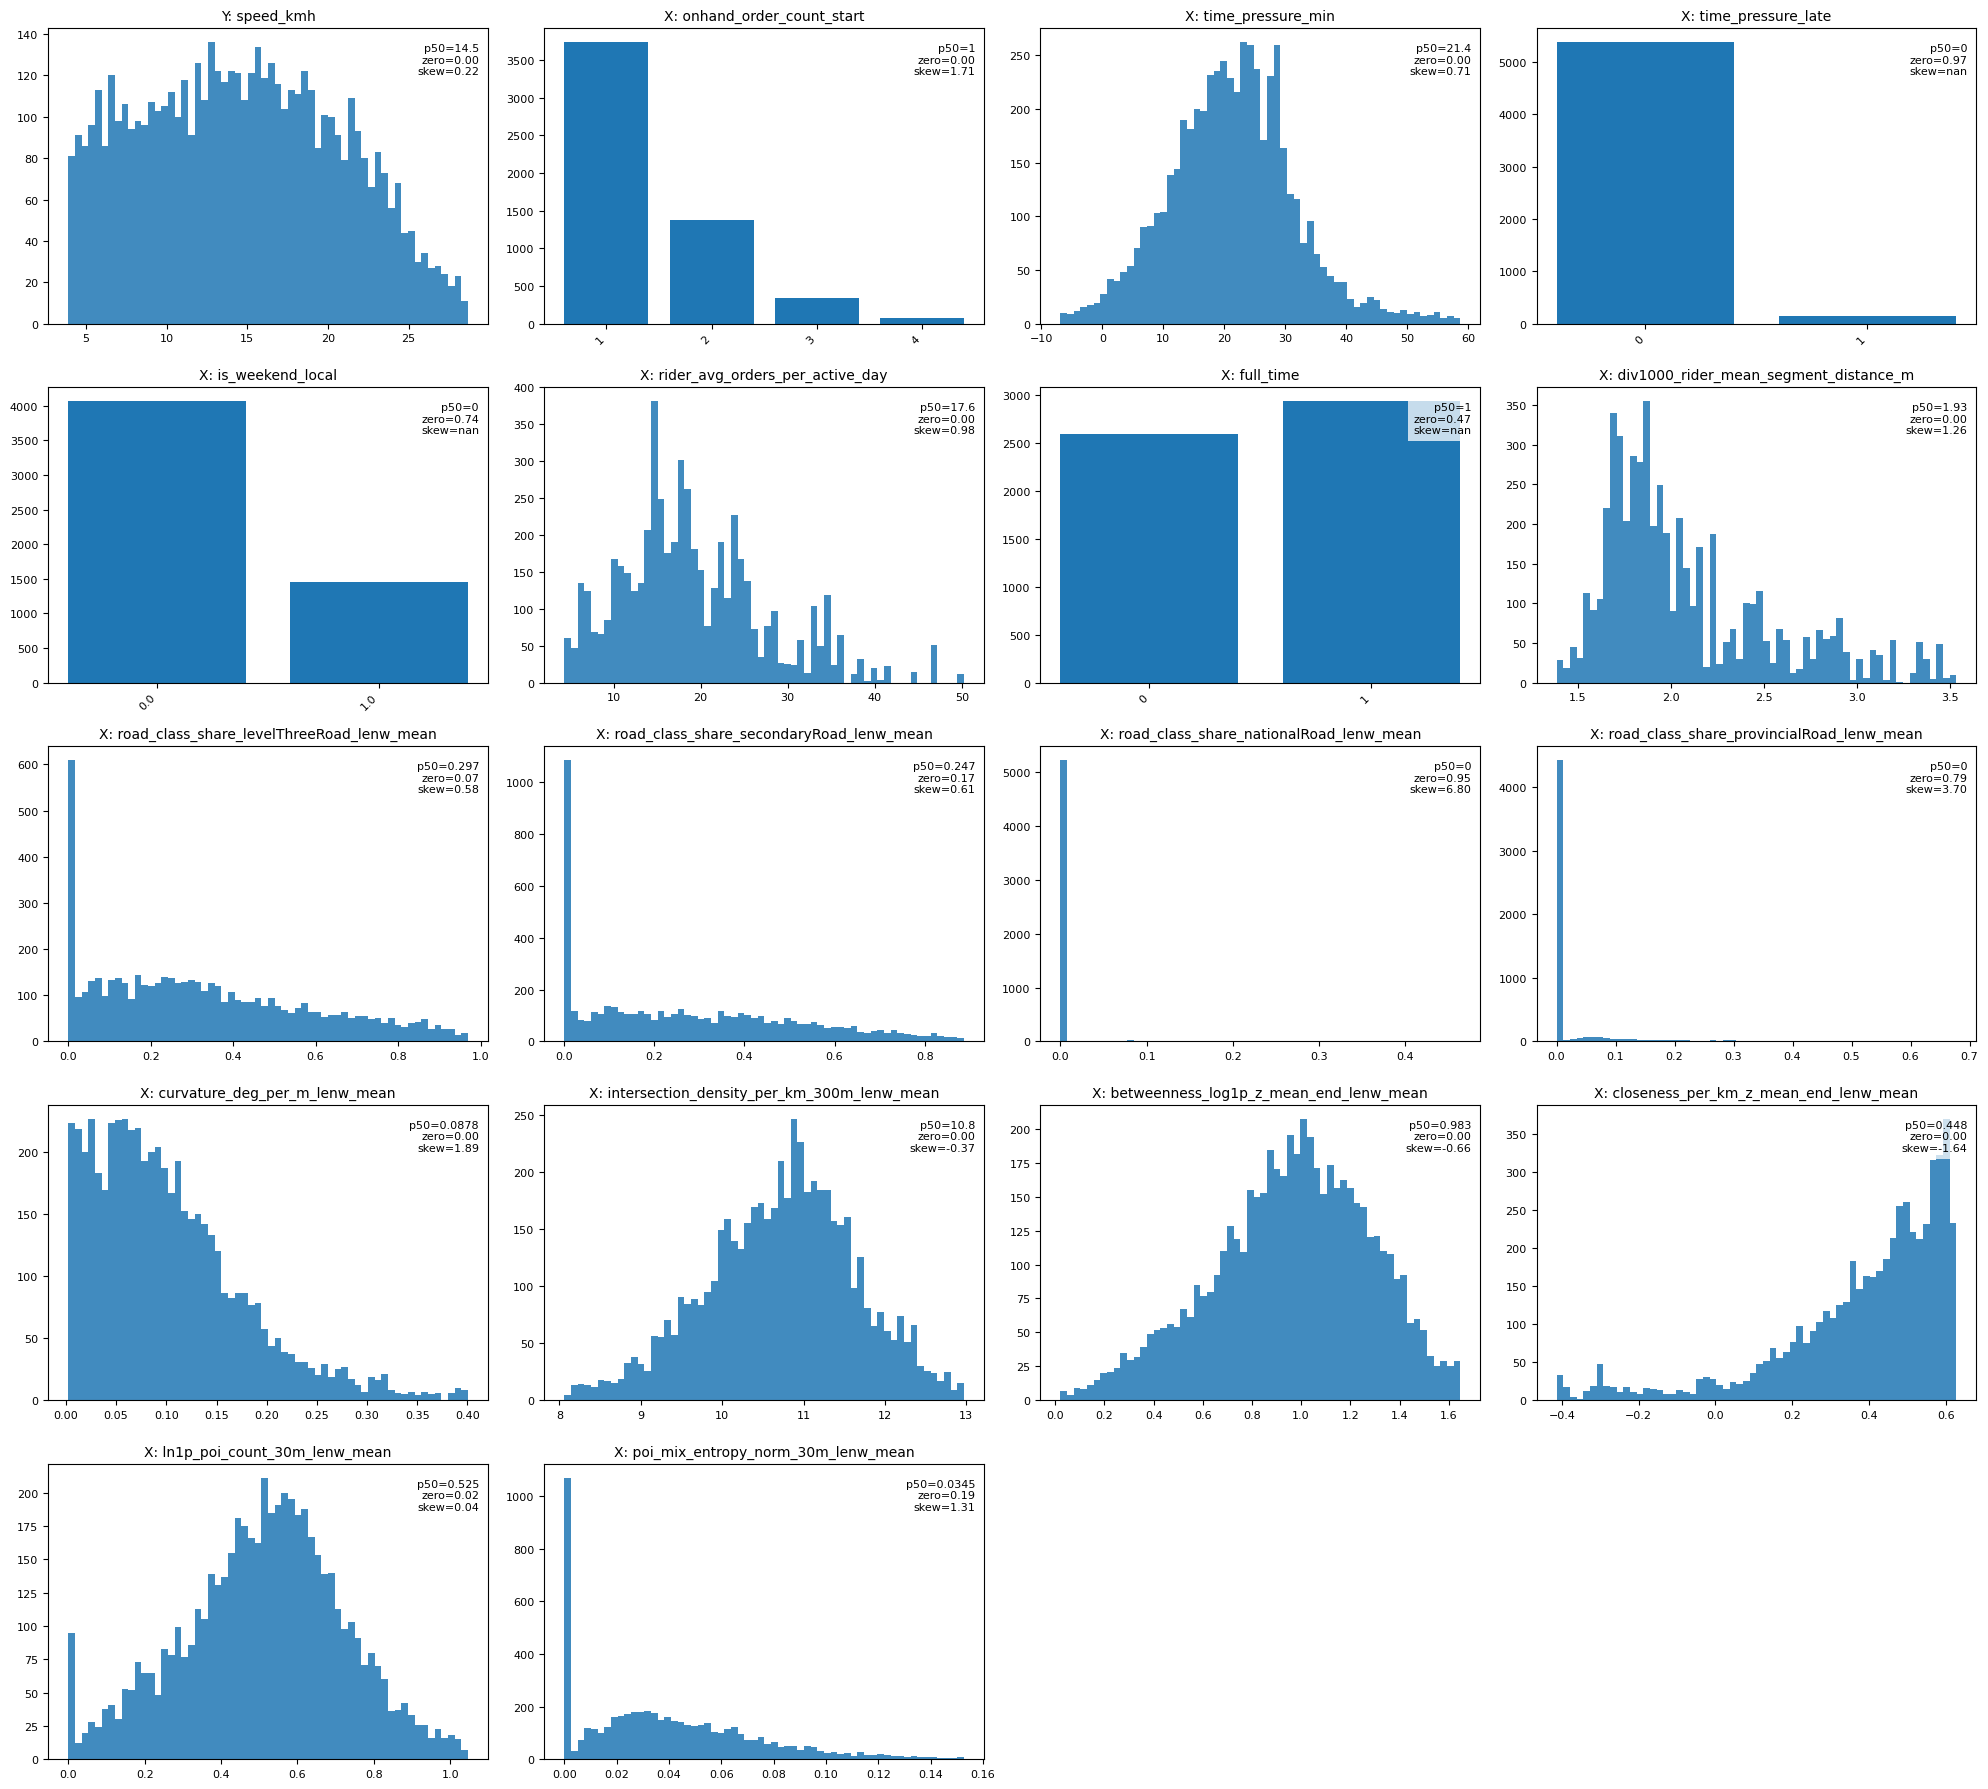

Saved distribution dashboard: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\05_time_heterogeneity_models\h02_06\plots\model_variable_distribution_dashboard.png
Top absolute correlations with Y:


,variable,corr_with_y
0,betweenness_log1p_z_mean_end_lenw_mean,0.268538
1,curvature_deg_per_m_lenw_mean,-0.189943
2,road_class_share_secondaryRoad_lenw_mean,0.179975
3,div1000_rider_mean_segment_distance_m,0.179554
4,intersection_density_per_km_300m_lenw_mean,-0.135741
5,road_class_share_provincialRoad_lenw_mean,0.130177
6,road_class_share_levelThreeRoad_lenw_mean,-0.100774
7,rider_avg_orders_per_active_day,-0.060655
8,time_pressure_min,-0.049075
9,onhand_order_count_start,0.043086


High pairwise X correlations, abs(corr) >= 0.85:


,var1,var2,corr,abs_corr


,model_name,y_col,y_base,y_transform,n_obs,n_params,r2,adj_r2,aic,bic,cov_type,cluster_col,condition_number,dropped_constant_cols,dropped_alias_cols,auto_dropped_high_vif_cols,alias_keep_preference_model_cols
0,ols_main,speed_kmh,speed_kmh,raw,5520,19,0.201,0.199,34866.506,34992.212,cluster,courier_id,1728.54,[],[],[],"[""poi_count_restaurant_30m_lenw_mean"", ""restau..."


...

Correct VIF table, computed with intercept:


,variable,VIF,aux_r2,n_obs,n_predictors_in_aux,status
0,ln1p_poi_count_30m_lenw_mean,4.215,0.763,100000,17,ok
1,poi_mix_entropy_norm_30m_lenw_mean,3.471,0.712,100000,17,ok
2,road_class_share_secondaryRoad_lenw_mean,2.328,0.570,100000,17,ok
3,closeness_per_km_z_mean_end_lenw_mean,2.224,0.550,100000,17,ok
4,road_class_share_levelThreeRoad_lenw_mean,2.183,0.542,100000,17,ok
5,betweenness_log1p_z_mean_end_lenw_mean,1.867,0.464,100000,17,ok
6,time_pressure_min,1.848,0.459,100000,17,ok
7,div1000_rider_mean_segment_distance_m,1.662,0.398,100000,17,ok
8,rider_avg_orders_per_active_day,1.614,0.381,100000,17,ok
9,road_class_share_provincialRoad_lenw_mean,1.483,0.326,100000,17,ok


Variable drop audit saved.
Skipped R2 diagnostics for this run.
Skipped XGBoost and SHAP for this run.
Done with run: h16_20
Full precision outputs: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\05_time_heterogeneity_models\h16_20\full_precision
Rounded outputs: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\05_time_heterogeneity_models\h16_20\rounded
Diagnostics: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\05_time_heterogeneity_models\h16_20\diagnostics
Plots: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\05_time_heterogeneity_models\h16_20\plots
Model comparison saved: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\05_time_heterogeneity_models\model_comparison.csv


,run_name,row_query,model_name,y_col,y_base,y_transform,n_obs,n_params,r2,adj_r2,...,cov_type,cluster_col,condition_number,dropped_constant_cols,dropped_alias_cols,auto_dropped_high_vif_cols,alias_keep_preference_model_cols,n_raw_x,n_model_x_before_dummies,n_interactions_created
0,h02_06,speed_kmh <= 40 and start_hour_local >= 2 and ...,ols_main,speed_kmh,speed_kmh,raw,5520,19,0.201,0.199,...,cluster,courier_id,1728.540,[],[],[],"[""poi_count_restaurant_30m_lenw_mean"", ""restau...",17,17,0
1,h10_14,speed_kmh <= 40 and start_hour_local >= 10 and...,ols_main,speed_kmh,speed_kmh,raw,151382,19,0.206,0.206,...,cluster,courier_id,1573.880,[],[],[],"[""poi_count_restaurant_30m_lenw_mean"", ""restau...",17,17,0
2,h16_20,speed_kmh <= 40 and start_hour_local >= 16 and...,ols_main,speed_kmh,speed_kmh,raw,149154,19,0.189,0.189,...,cluster,courier_id,1628.384,[],[],[],"[""poi_count_restaurant_30m_lenw_mean"", ""restau...",17,17,0



Primary run exposed as legacy variables: h02_06
Selected raw X count: 17
Selected model X count: 17


In [11]:
# =========================================================
# 10. Run model specifications and save effective configuration
# =========================================================
def format_python_list(name, values, indent="    "):
    lines = [name + " = ["]
    for v in values:
        lines.append(indent + repr(str(v)) + ",")
    lines.append("]")
    return "\n".join(lines)


def save_effective_configuration(prep, run_name, row_query):
    effective_config = {
        "run_name": run_name,
        "trip_table_path": str(TRIP_TABLE_PATH),
        "base_output_root": str(BASE_OUTPUT_ROOT),
        "output_root": str(OUTPUT_ROOT),
        "full_precision_dir": str(FULL_PRECISION_DIR),
        "rounded_dir": str(ROUNDED_DIR),
        "y_col": Y_COL,
        "y_transform": Y_TRANSFORM,
        "row_query": row_query,
        "cluster_col": CLUSTER_COL,
        "run_multiple_model_specs": RUN_MULTIPLE_MODEL_SPECS,
        "primary_run_name": PRIMARY_RUN_NAME,
        "model_run_specs": dict(MODEL_RUN_SPECS),
        "x_groups": {k: list(v) for k, v in X_GROUPS.items()},
        "x_extra": X_EXTRA,
        "x_drop": X_DROP,
        "categorical_vars": CATEGORICAL_VARS,
        "derived_variable_specs": DERIVED_VARIABLE_SPECS,
        "add_interactions": ADD_INTERACTIONS,
        "interaction_specs": INTERACTION_SPECS,
        "drop_mechanical_x_when_y_is_speed": DROP_MECHANICAL_X_WHEN_Y_IS_SPEED,
        "mechanical_x_when_y_speed": MECHANICAL_X_WHEN_Y_SPEED,
        "drop_one_road_class_reference": DROP_ONE_ROAD_CLASS_REFERENCE,
        "road_class_reference_mode": ROAD_CLASS_REFERENCE_MODE,
        "road_class_reference_used": prep.get("road_class_reference"),
        "variable_transforms": dict(VARIABLE_TRANSFORMS),
        "pattern_variable_transforms": dict(PATTERN_VARIABLE_TRANSFORMS),
        "auto_apply_recommended_transforms": AUTO_APPLY_RECOMMENDED_TRANSFORMS,
        "alias_keep_preference_raw": ALIAS_KEEP_PREFERENCE_RAW,
        "auto_drop_high_vif": AUTO_DROP_HIGH_VIF,
        "vif_threshold": VIF_THRESHOLD,
        "vif_max_rows": VIF_MAX_ROWS,
        "vif_driver_max_rows": VIF_DRIVER_MAX_ROWS,
        "run_ols": RUN_OLS,
        "run_xgboost_shap": RUN_XGBOOST_SHAP,
        "xgb_params": XGB_PARAMS,
    }
    save_json(effective_config, OUTPUT_ROOT / "effective_config.json")

    copy_text = []
    copy_text.append("Y_COL = %r" % Y_COL)
    copy_text.append("Y_TRANSFORM = %r" % Y_TRANSFORM)
    copy_text.append("ROW_QUERY = %r" % row_query)
    copy_text.append("")
    copy_text.append(format_python_list("X_SELECTED_RAW", prep["x_raw"]))
    copy_text.append("")
    copy_text.append(format_python_list("X_SELECTED_MODEL", prep["x_model"]))
    save_text("\n".join(copy_text), DIAGNOSTICS_DIR / "final_selected_x_y_block.py")


def run_one_model_spec(run_name, row_query, run_dashboard=False, run_r2=False, run_xgb=False):
    set_output_dirs_for_run(run_name)
    print("")
    print("=" * 80)
    print("Running model spec:", run_name)
    print("Row query:", row_query)
    print("Output root:", OUTPUT_ROOT)

    trip_df_local = load_and_filter_trip_table(row_query=row_query)
    prep = prepare_modeling_data(trip_df_local)
    save_preparation_outputs(prep)

    if run_dashboard:
        variable_distribution_summary_local = make_variable_distribution_dashboard(prep)
    else:
        variable_distribution_summary_local = None
        print("Skipped distribution dashboard for this run.")

    if RUN_OLS:
        ols_out = run_ols(prep)
        display(round_numeric_columns(ols_out["fit_info"], 3))
        display(round_numeric_columns(ols_out["coef"].head(50), 3))
        print("Correct VIF table, computed with intercept:")
        display(round_numeric_columns(ols_out["vif_after"], 3))
    else:
        ols_out = None
        print("RUN_OLS is False. Skipped OLS.")

    variable_drop_audit_local = make_variable_drop_audit(prep, ols_out, trip_df_local)
    write_result_table(variable_drop_audit_local, "diagnostics/variable_drop_audit.csv", index=False, rounded=True)
    print("Variable drop audit saved.")

    if run_r2:
        r2_diagnostics_local = run_r2_diagnostics(prep)
    else:
        r2_diagnostics_local = None
        print("Skipped R2 diagnostics for this run.")

    if run_xgb:
        xgb_shap_results_local = run_xgboost_shap(prep)
    else:
        xgb_shap_results_local = None
        print("Skipped XGBoost and SHAP for this run.")

    save_effective_configuration(prep, run_name, row_query)

    fit_info = pd.DataFrame()
    if ols_out is not None:
        fit_info = ols_out["fit_info"].copy()
        fit_info.insert(0, "run_name", run_name)
        fit_info.insert(1, "row_query", row_query)
        fit_info["n_raw_x"] = len(prep["x_raw"])
        fit_info["n_model_x_before_dummies"] = len(prep["x_model"])
        fit_info["n_interactions_created"] = int((prep["interaction_info"].get("status", pd.Series(dtype=str)) == "created").sum()) if len(prep["interaction_info"]) else 0

    print("Done with run:", run_name)
    print("Full precision outputs:", FULL_PRECISION_DIR)
    print("Rounded outputs:", ROUNDED_DIR)
    print("Diagnostics:", DIAGNOSTICS_DIR)
    print("Plots:", PLOTS_DIR)

    return {
        "run_name": run_name,
        "row_query": row_query,
        "trip_df": trip_df_local,
        "prepared": prep,
        "variable_distribution_summary": variable_distribution_summary_local,
        "ols": ols_out,
        "variable_drop_audit": variable_drop_audit_local,
        "r2_diagnostics": r2_diagnostics_local,
        "xgb_shap": xgb_shap_results_local,
        "fit_info": fit_info,
    }


def write_model_comparison(run_outputs):
    fit_rows = []
    for out in run_outputs.values():
        fit = out.get("fit_info")
        if fit is not None and len(fit) > 0:
            fit_rows.append(fit)

    if len(fit_rows) == 0:
        print("No OLS fit rows to compare.")
        return pd.DataFrame()

    model_comparison = pd.concat(fit_rows, ignore_index=True)
    ensure_dir(BASE_OUTPUT_ROOT)
    write_csv_atomic(model_comparison, BASE_OUTPUT_ROOT / "model_comparison_full_precision.csv", index=False)
    write_csv_atomic(round_numeric_columns(model_comparison, 3), BASE_OUTPUT_ROOT / "model_comparison.csv", index=False)
    print("Model comparison saved:", BASE_OUTPUT_ROOT / "model_comparison.csv")
    display(round_numeric_columns(model_comparison, 3))
    return model_comparison


if RUN_MULTIPLE_MODEL_SPECS:
    run_specs = MODEL_RUN_SPECS
else:
    run_specs = OrderedDict([("single_run", ROW_QUERY)])

if PRIMARY_RUN_NAME not in run_specs:
    PRIMARY_RUN_NAME_EFFECTIVE = next(iter(run_specs.keys()))
else:
    PRIMARY_RUN_NAME_EFFECTIVE = PRIMARY_RUN_NAME

run_outputs = OrderedDict()
for run_name, row_query in run_specs.items():
    is_primary = run_name == PRIMARY_RUN_NAME_EFFECTIVE
    run_outputs[run_name] = run_one_model_spec(
        run_name=run_name,
        row_query=row_query,
        run_dashboard=RUN_VARIABLE_DISTRIBUTION_DASHBOARD and (RUN_DISTRIBUTION_DASHBOARD_FOR_ALL_SPECS or is_primary),
        run_r2=RUN_R2_DIAGNOSTICS and (RUN_R2_DIAGNOSTICS_FOR_ALL_SPECS or is_primary),
        run_xgb=RUN_XGBOOST_SHAP and (RUN_XGBOOST_SHAP_FOR_ALL_SPECS or is_primary),
    )

model_comparison = write_model_comparison(run_outputs)

# Expose the primary run under the old variable names for compatibility with older ad hoc cells.
primary_output = run_outputs[PRIMARY_RUN_NAME_EFFECTIVE]
trip_df = primary_output["trip_df"]
prepared = primary_output["prepared"]
variable_distribution_summary = primary_output["variable_distribution_summary"]
ols_results = primary_output["ols"]
variable_drop_audit = primary_output["variable_drop_audit"]
r2_diagnostics = primary_output["r2_diagnostics"]
xgb_shap_results = primary_output["xgb_shap"]

set_output_dirs_for_run(PRIMARY_RUN_NAME_EFFECTIVE)
print("")
print("Primary run exposed as legacy variables:", PRIMARY_RUN_NAME_EFFECTIVE)
print("Selected raw X count:", len(prepared["x_raw"]))
print("Selected model X count:", len(prepared["x_model"]))


## Time heterogeneity coefficient comparison

This block combines the three selected four-hour OLS outputs into long and wide coefficient tables.


In [12]:
# =========================================================
# 11. Time heterogeneity LME models and coefficient comparison
#     Three selected four-hour models side by side
#     Ordered and compact, following the section 04 OLS table style
#     Python 3.8 compatible
# =========================================================

from pathlib import Path
from collections import OrderedDict
import os
import re
import json
import numpy as np
import pandas as pd
import statsmodels.api as sm


# ---------------------------------------------------------
# 11.0 LME configuration
# ---------------------------------------------------------

RUN_LINEAR_MIXED_EFFECTS_MODEL = True

# Main hierarchy. Repeated trip segments from the same courier are not independent.
LME_PRIMARY_GROUP_COL = "courier_id"

# Optional additional random-intercept layers through statsmodels MixedLM vc_formula.
# Examples:
# LME_ADDITIONAL_GROUP_COLS = ["da_id", "dt"]
LME_ADDITIONAL_GROUP_COLS = []

# Optional combined variance-component groups.
# Example: {"name": "courier_day", "cols": ["courier_id", "dt"]}
LME_ADDITIONAL_GROUP_SPECS = []

# Optional random slopes. Keep empty for a stable random-intercept baseline.
# Example: LME_RANDOM_SLOPE_VARS = ["final_distance_m__log1p"]
LME_RANDOM_SLOPE_VARS = []

LME_REML = False
LME_METHOD_SEQUENCE = ["powell", "lbfgs", "cg"]
LME_MAXITER = 500
LME_USE_SPARSE_VC = True

# Reject degenerate optimizer results instead of saving them.
# The common bad case is: llf = inf, AIC = -inf, random-intercept variance = 0,
# and huge fixed-effect standard errors. That result should be skipped and the next optimizer tried.
LME_REJECT_NONFINITE_LLF = True
LME_REJECT_HUGE_FIXED_EFFECT_SE = True
LME_HUGE_FIXED_EFFECT_SE_THRESHOLD = 1e5

LME_MAX_ROWS = None
LME_SAMPLE_RANDOM_STATE = RANDOM_SEED if "RANDOM_SEED" in globals() else 42
LME_MIN_PRIMARY_GROUP_SIZE = 2
LME_MAX_FIXED_EFFECTS = None
LME_FIXED_EFFECT_PRIORITY_VARS = []

# For 05, the key output is the fixed-effect comparison across windows.
# Keep random-effect export off by default to avoid very large files for three separate LME fits.
SAVE_LME_RANDOM_EFFECTS = False

TIME_HET_EXPORT_DIR = BASE_OUTPUT_ROOT / "coef_comparison_lme"
TIME_HET_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

TIME_HET_LME_COEF_LONG_CSV = TIME_HET_EXPORT_DIR / "time_heterogeneity_lme_fixed_effects_long.csv"
TIME_HET_LME_COEF_WIDE_CSV = TIME_HET_EXPORT_DIR / "time_heterogeneity_lme_fixed_effects_wide.csv"
TIME_HET_LME_COEF_WIDE_PRETTY_CSV = TIME_HET_EXPORT_DIR / "time_heterogeneity_lme_fixed_effects_wide_pretty.csv"
TIME_HET_LME_FIT_COMPARISON_CSV = TIME_HET_EXPORT_DIR / "time_heterogeneity_lme_fit_comparison.csv"
TIME_HET_LME_VARIABLE_PRESENCE_CSV = TIME_HET_EXPORT_DIR / "time_heterogeneity_lme_variable_presence.csv"

TH_OUTPUT_DIGITS = 4
TH_METRIC_ORDER = ["coef", "std_err", "z_value", "p_value", "ci_low", "ci_high"]
TH_VAR_FRONT_COLS = ["variable_group", "variable", "variable_base"]



def th_window_info(run_name):
    if "TIME_HETEROGENEITY_WINDOWS" in globals() and run_name in TIME_HETEROGENEITY_WINDOWS:
        info = TIME_HETEROGENEITY_WINDOWS[run_name]
        return info.get("label", run_name), info.get("hour_start", np.nan), info.get("hour_end", np.nan)
    return run_name, np.nan, np.nan

def time_lme_set_output_paths_for_run(run_name):
    """Point LME output paths to the current time-window run folder."""
    global LME_RUN_NAME, LME_OUTPUT_DIR
    global LME_FIXED_EFFECTS_CSV, LME_FIXED_EFFECTS_PRETTY_CSV, LME_FIT_INFO_CSV
    global LME_VARIANCE_COMPONENTS_CSV, LME_RANDOM_EFFECTS_CSV, LME_DESIGN_MAP_CSV
    global LME_SUMMARY_TXT, LME_CONFIG_JSON

    LME_RUN_NAME = run_name
    set_output_dirs_for_run(run_name)

    LME_OUTPUT_DIR = OUTPUT_ROOT / "linear_mixed_effects"
    LME_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    LME_FIXED_EFFECTS_CSV = LME_OUTPUT_DIR / "lme_fixed_effects.csv"
    LME_FIXED_EFFECTS_PRETTY_CSV = LME_OUTPUT_DIR / "lme_fixed_effects_pretty.csv"
    LME_FIT_INFO_CSV = LME_OUTPUT_DIR / "lme_fit_info.csv"
    LME_VARIANCE_COMPONENTS_CSV = LME_OUTPUT_DIR / "lme_variance_components.csv"
    LME_RANDOM_EFFECTS_CSV = LME_OUTPUT_DIR / "lme_random_effects_by_group.csv"
    LME_DESIGN_MAP_CSV = LME_OUTPUT_DIR / "lme_design_column_map.csv"
    LME_SUMMARY_TXT = LME_OUTPUT_DIR / "lme_summary.txt"
    LME_CONFIG_JSON = LME_OUTPUT_DIR / "lme_config.json"

    return LME_OUTPUT_DIR

def lme_safe_group_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in {"", "nan", "None", "<NA>"}:
        return np.nan
    return s


def lme_make_group_column(df, spec):
    name = str(spec.get("name", "")).strip()
    cols = list(spec.get("cols", []))
    if name == "":
        name = "group_" + "_x_".join([str(c) for c in cols])
    out_col = "lme_vc_" + re.sub(r"[^A-Za-z0-9_]+", "_", name).strip("_")
    missing = [c for c in cols if c not in df.columns]
    if len(missing) > 0:
        raise ValueError("LME additional group spec %s has missing columns: %s" % (name, missing))
    df[out_col] = df[cols].apply(
        lambda r: "|".join([str(lme_safe_group_value(v)) for v in r.values]),
        axis=1,
    )
    df[out_col] = df[out_col].replace({"nan": np.nan, "nan|nan": np.nan})
    return out_col, name


def lme_prepare_numeric_design(X):
    """Return a purely numeric float design matrix for MixedLM formulas.

    Patsy treats boolean columns in a formula as categorical variables.
    That creates model terms like x0021[T.True]. Converting all design
    columns to float keeps the fitted parameter names as x0021, and the
    design_map can recover the human-readable original variable names.
    """
    X_num = X.copy()
    for c in X_num.columns:
        X_num[c] = pd.to_numeric(X_num[c], errors="coerce")
    return X_num.astype(float)


def lme_safe_base_term(term):
    """Extract the base safe variable from a patsy term.

    Handles terms such as x0021, x0021[T.True], C(x0021)[T.True],
    and simple interaction terms separated by colon.
    """
    term = str(term)
    if term == "Intercept":
        return "Intercept"

    def one_part(part):
        part = str(part)
        if part == "Intercept":
            return "Intercept"
        m = re.match(r"^(x\d{4})(?:\[T\..*\])?$", part)
        if m:
            return m.group(1)
        m = re.match(r"^C\((x\d{4})\)(?:\[T\..*\])?$", part)
        if m:
            return m.group(1)
        return part

    if ":" in term:
        return ":".join([one_part(p) for p in term.split(":")])
    return one_part(term)


def lme_human_readable_term(term, name_map):
    """Map a fitted MixedLM term back to the original design variable name."""
    term = str(term)
    if term == "Intercept":
        return "Intercept"

    def one_part(part):
        base = lme_safe_base_term(part)
        return name_map.get(base, part)

    if ":" in term:
        return ":".join([one_part(p) for p in term.split(":")])

    base = lme_safe_base_term(term)
    return name_map.get(base, term)


def lme_build_fixed_effect_design(prep):
    df_model = prep["df_model"].copy()
    y_col = prep["y_model"]
    x_cols = list(prep["x_model"])
    cat_cols = list(prep["cat_cols"])

    preferred = []
    try:
        preferred = alias_keep_model_names(prep.get("x_rules", {}))
    except Exception:
        preferred = []

    X, dropped_constant = build_design_matrix(
        df_model,
        cont_cols=x_cols,
        cat_cols=cat_cols,
        add_const=False,
        preferred_order=preferred,
    )
    X = X.replace([np.inf, -np.inf], np.nan)

    # MixedLM.from_formula uses patsy. Boolean columns are interpreted as
    # categorical and produce names such as x0021[T.True]. Force all fixed
    # effects to numeric float before alias checks and before fitting.
    X = lme_prepare_numeric_design(X)

    # Remove exact aliases to reduce singular matrix risk in MixedLM.
    X_alias_checked, dropped_alias = drop_exact_alias_columns(X, protect_cols=[])
    X_alias_checked = lme_prepare_numeric_design(X_alias_checked)

    if LME_MAX_FIXED_EFFECTS is not None and X_alias_checked.shape[1] > int(LME_MAX_FIXED_EFFECTS):
        priority = [c for c in LME_FIXED_EFFECT_PRIORITY_VARS if c in X_alias_checked.columns]
        rest = [c for c in X_alias_checked.columns if c not in set(priority)]
        keep = (priority + rest)[:int(LME_MAX_FIXED_EFFECTS)]
        dropped_width = [c for c in X_alias_checked.columns if c not in set(keep)]
        X_alias_checked = X_alias_checked[keep].copy()
    else:
        dropped_width = []

    X_alias_checked = lme_prepare_numeric_design(X_alias_checked)

    x_safe_cols = ["x%04d" % i for i in range(X_alias_checked.shape[1])]
    design_map = pd.DataFrame({
        "safe_variable": x_safe_cols,
        "original_variable": list(X_alias_checked.columns),
    })

    X_safe = X_alias_checked.copy()
    X_safe.columns = x_safe_cols
    X_safe = lme_prepare_numeric_design(X_safe)

    return df_model, y_col, X_safe, design_map, dropped_constant, dropped_alias, dropped_width


def lme_resolve_random_slope_terms(design_map):
    if len(LME_RANDOM_SLOPE_VARS) == 0:
        return [], []

    original_to_safe = dict(zip(design_map["original_variable"], design_map["safe_variable"]))
    safe_set = set(design_map["safe_variable"])

    safe_terms = []
    unresolved = []
    for v in LME_RANDOM_SLOPE_VARS:
        if v in safe_set:
            safe_terms.append(v)
        elif v in original_to_safe:
            safe_terms.append(original_to_safe[v])
        else:
            unresolved.append(v)

    safe_terms = list(OrderedDict.fromkeys(safe_terms))
    return safe_terms, unresolved


def lme_prepare_dataset(prep):
    df_model, y_col, X_safe, design_map, dropped_constant, dropped_alias, dropped_width = lme_build_fixed_effect_design(prep)

    if LME_PRIMARY_GROUP_COL not in df_model.columns:
        raise ValueError("LME primary group column is missing: %s" % LME_PRIMARY_GROUP_COL)

    use = pd.concat(
        [
            pd.DataFrame({"lme_y": pd.to_numeric(df_model[y_col], errors="coerce")}, index=df_model.index),
            X_safe,
            df_model[[LME_PRIMARY_GROUP_COL]].copy(),
        ],
        axis=1,
    )

    use["lme_primary_group"] = df_model[LME_PRIMARY_GROUP_COL].map(lme_safe_group_value)

    for c in X_safe.columns:
        use[c] = pd.to_numeric(use[c], errors="coerce").astype(float)

    vc_formula = OrderedDict()
    vc_source_rows = []

    for col in LME_ADDITIONAL_GROUP_COLS:
        if col not in df_model.columns:
            raise ValueError("LME additional group column is missing: %s" % col)
        safe_col = "lme_vc_" + re.sub(r"[^A-Za-z0-9_]+", "_", str(col)).strip("_")
        use[safe_col] = df_model[col].map(lme_safe_group_value)
        vc_name = re.sub(r"[^A-Za-z0-9_]+", "_", str(col)).strip("_")
        vc_formula[vc_name] = "0 + C(%s)" % safe_col
        vc_source_rows.append({"variance_component": vc_name, "source_type": "column", "source": col, "safe_column": safe_col})

    for spec in LME_ADDITIONAL_GROUP_SPECS:
        safe_col, name = lme_make_group_column(df_model, spec)
        use[safe_col] = df_model[safe_col].map(lme_safe_group_value)
        vc_name = re.sub(r"[^A-Za-z0-9_]+", "_", str(name)).strip("_")
        vc_formula[vc_name] = "0 + C(%s)" % safe_col
        vc_source_rows.append({"variance_component": vc_name, "source_type": "combined", "source": json.dumps(spec, ensure_ascii=False), "safe_column": safe_col})

    required = ["lme_y", "lme_primary_group"] + list(X_safe.columns)
    for row in vc_source_rows:
        required.append(row["safe_column"])

    use = use.replace([np.inf, -np.inf], np.nan)
    before_dropna = len(use)
    use = use.dropna(subset=required).copy()

    group_counts = use["lme_primary_group"].value_counts(dropna=False)
    keep_groups = set(group_counts[group_counts >= int(LME_MIN_PRIMARY_GROUP_SIZE)].index)
    before_group_filter = len(use)
    use = use[use["lme_primary_group"].isin(keep_groups)].copy()

    if LME_MAX_ROWS is not None and len(use) > int(LME_MAX_ROWS):
        # Group-aware sampling: sample rows after filtering, then re-check group sizes.
        use = use.sample(int(LME_MAX_ROWS), random_state=LME_SAMPLE_RANDOM_STATE).copy()
        group_counts = use["lme_primary_group"].value_counts(dropna=False)
        keep_groups = set(group_counts[group_counts >= int(LME_MIN_PRIMARY_GROUP_SIZE)].index)
        use = use[use["lme_primary_group"].isin(keep_groups)].copy()

    if len(use) < 100:
        raise ValueError("Too few rows for LME after filters: %d" % len(use))

    if use["lme_primary_group"].nunique() < 2:
        raise ValueError("LME needs at least two primary groups after filters.")

    diagnostics = {
        "n_rows_before_dropna": int(before_dropna),
        "n_rows_after_dropna": int(before_group_filter),
        "n_rows_after_group_filter_and_sample": int(len(use)),
        "n_primary_groups": int(use["lme_primary_group"].nunique()),
        "min_primary_group_size": int(use["lme_primary_group"].value_counts().min()),
        "median_primary_group_size": float(use["lme_primary_group"].value_counts().median()),
        "max_primary_group_size": int(use["lme_primary_group"].value_counts().max()),
        "n_fixed_effects": int(X_safe.shape[1]),
        "dropped_constant_columns": list(dropped_constant),
        "dropped_exact_alias_columns": list(dropped_alias),
        "dropped_width_limit_columns": list(dropped_width),
        "vc_sources": vc_source_rows,
    }

    return use, y_col, design_map, vc_formula, diagnostics


def lme_result_health_check(result):
    """Return (is_valid, reason) for a fitted MixedLM result.

    Some optimizers can return a formally converged but degenerate boundary result.
    In this project, the bad pattern is usually llf = inf, AIC = -inf,
    random-intercept variance = 0, Intercept near 0, and huge fixed-effect standard errors.
    """
    if result is None:
        return False, "empty result"

    if not bool(getattr(result, "converged", False)):
        return False, "not converged"

    llf = getattr(result, "llf", np.nan)
    if bool(LME_REJECT_NONFINITE_LLF) and not np.isfinite(llf):
        return False, "non-finite log likelihood: %s" % str(llf)

    scale = getattr(result, "scale", np.nan)
    if not np.isfinite(scale) or scale <= 0:
        return False, "invalid residual scale: %s" % str(scale)

    try:
        bse_fe = pd.Series(result.bse_fe)
    except Exception:
        try:
            fe_index = pd.Series(result.fe_params).index
            bse_fe = pd.Series(result.bse).reindex(fe_index)
        except Exception:
            bse_fe = pd.Series(dtype=float)

    if len(bse_fe) > 0:
        bse_num = pd.to_numeric(bse_fe, errors="coerce")
        if not np.all(np.isfinite(bse_num)):
            return False, "non-finite fixed-effect standard errors"
        max_bse = float(np.nanmax(np.abs(bse_num)))
        if bool(LME_REJECT_HUGE_FIXED_EFFECT_SE) and max_bse > float(LME_HUGE_FIXED_EFFECT_SE_THRESHOLD):
            return False, "huge fixed-effect standard error: %.6g" % max_bse

    return True, "ok"


def lme_fit_model(data, design_map, vc_formula):
    x_terms = list(design_map["safe_variable"])
    formula = "lme_y ~ " + " + ".join(x_terms) if len(x_terms) > 0 else "lme_y ~ 1"

    slope_terms, unresolved_slopes = lme_resolve_random_slope_terms(design_map)
    if len(slope_terms) > 0:
        re_formula = "1 + " + " + ".join(slope_terms)
    else:
        re_formula = "1"

    fit_errors = []
    model = sm.MixedLM.from_formula(
        formula=formula,
        groups="lme_primary_group",
        re_formula=re_formula,
        vc_formula=dict(vc_formula) if len(vc_formula) > 0 else None,
        data=data,
        use_sparse=LME_USE_SPARSE_VC,
    )

    last_error = None
    best_invalid = None
    for method in LME_METHOD_SEQUENCE:
        try:
            result = model.fit(
                reml=bool(LME_REML),
                method=method,
                maxiter=int(LME_MAXITER),
                full_output=True,
                disp=False,
            )
            is_valid, reason = lme_result_health_check(result)
            if is_valid:
                return result, method, fit_errors, unresolved_slopes

            fit_errors.append({"method": method, "error": "degenerate result rejected: " + reason})
            print("LME fit with method %s was rejected: %s" % (method, reason))
            if best_invalid is None:
                best_invalid = (result, method, reason)
        except Exception as exc:
            last_error = exc
            fit_errors.append({"method": method, "error": repr(exc)})
            print("LME fit failed with method %s: %s" % (method, repr(exc)))

    if best_invalid is not None:
        result, method, reason = best_invalid
        raise RuntimeError(
            "All LME optimizers failed or produced degenerate results. "
            "Best invalid method was %s: %s. Details: %s" % (method, reason, fit_errors)
        ) from last_error

    raise RuntimeError("All LME optimizers failed: %s" % fit_errors) from last_error


def lme_p_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    if p < 0.1:
        return "+"
    return ""


def lme_format_coef_with_sig(coef_value, p_value, digits=4):
    if pd.isna(coef_value):
        return ""
    return (("%%.%df" % int(digits)) % float(coef_value)) + lme_p_stars(p_value)


def lme_reorder_fixed_effect_columns(coef):
    front_cols = [
        "variable_group",
        "variable",
        "variable_base",
        "coef",
        "std_err",
        "z_value",
        "p_value",
        "ci_low",
        "ci_high",
        "sig",
        "coef_with_sig",
        "y_col",
        "x_standardized_for_estimation",
        "model_term",
        "safe_variable",
    ]
    front_cols = [c for c in front_cols if c in coef.columns]
    rest_cols = [c for c in coef.columns if c not in front_cols and not str(c).startswith("_")]
    return coef[front_cols + rest_cols].copy()


def lme_fixed_effects_pretty_table(fixed_effects):
    if fixed_effects is None or len(fixed_effects) == 0:
        return pd.DataFrame()

    pretty = fixed_effects.copy()
    if "coef_with_sig" not in pretty.columns:
        pretty["coef_with_sig"] = [
            lme_format_coef_with_sig(c, p)
            for c, p in zip(pretty.get("coef", pd.Series(dtype=float)), pretty.get("p_value", pd.Series(dtype=float)))
        ]

    keep = [
        "variable_group",
        "variable",
        "variable_base",
        "coef_with_sig",
        "std_err",
        "z_value",
        "p_value",
        "ci_low",
        "ci_high",
        "y_col",
    ]
    keep = [c for c in keep if c in pretty.columns]
    return pretty[keep].copy()


def lme_fixed_effects_table(result, design_map, prep=None, y_col=None):
    name_map = dict(zip(design_map["safe_variable"], design_map["original_variable"]))
    name_map["Intercept"] = "const"

    fe = pd.Series(result.fe_params)
    bse = pd.Series(result.bse)
    pvals = pd.Series(result.pvalues)

    try:
        ci = result.conf_int()
        ci.columns = ["ci_low", "ci_high"]
    except Exception:
        ci = pd.DataFrame(index=fe.index, columns=["ci_low", "ci_high"], dtype=float)

    rows = []
    for name, coef in fe.items():
        se = bse.get(name, np.nan)
        z_value = coef / se if pd.notna(se) and se != 0 else np.nan
        safe_base = lme_safe_base_term(name)
        readable_name = lme_human_readable_term(name, name_map)
        if name == "Intercept" or readable_name == "Intercept":
            readable_name = "const"
            safe_base = "const"
        rows.append({
            "variable": readable_name,
            "model_term": name,
            "safe_variable": safe_base,
            "coef": float(coef) if pd.notna(coef) else np.nan,
            "std_err": float(se) if pd.notna(se) else np.nan,
            "z_value": float(z_value) if pd.notna(z_value) else np.nan,
            "p_value": float(pvals.get(name, np.nan)) if pd.notna(pvals.get(name, np.nan)) else np.nan,
            "ci_low": float(ci.loc[name, "ci_low"]) if name in ci.index and pd.notna(ci.loc[name, "ci_low"]) else np.nan,
            "ci_high": float(ci.loc[name, "ci_high"]) if name in ci.index and pd.notna(ci.loc[name, "ci_high"]) else np.nan,
        })

    out = pd.DataFrame(rows)
    if len(out) == 0:
        return out

    # Use exactly the same variable group and within-group ordering logic as the OLS table.
    if prep is not None and "add_coef_group_order" in globals():
        try:
            out = add_coef_group_order(out, prep)
        except Exception:
            out["variable_base"] = out["variable"].astype(str)
            out["variable_group"] = np.where(out["variable"].astype(str).eq("const"), "constant", "other")
            out = out.sort_values(["variable_group", "variable"]).reset_index(drop=True)
    else:
        out["variable_base"] = out["variable"].astype(str)
        out["variable_group"] = np.where(out["variable"].astype(str).eq("const"), "constant", "other")
        out = out.sort_values(["variable_group", "variable"]).reset_index(drop=True)

    out["sig"] = out["p_value"].apply(lme_p_stars)
    out["coef_with_sig"] = [lme_format_coef_with_sig(c, p) for c, p in zip(out["coef"], out["p_value"])]
    out["y_col"] = y_col if y_col is not None else diagnostics.get("y_col", "") if "diagnostics" in globals() else ""
    out["x_standardized_for_estimation"] = False

    out = lme_reorder_fixed_effect_columns(out)
    return out

def lme_variance_components_table(result, vc_formula):
    rows = []

    try:
        cov_re = result.cov_re
        if hasattr(cov_re, "shape") and cov_re.shape[0] > 0:
            for i in range(cov_re.shape[0]):
                for j in range(cov_re.shape[1]):
                    rows.append({
                        "component": "primary_group_cov_re",
                        "term_i": str(cov_re.index[i]) if hasattr(cov_re, "index") else str(i),
                        "term_j": str(cov_re.columns[j]) if hasattr(cov_re, "columns") else str(j),
                        "variance_or_covariance": float(cov_re.iloc[i, j]),
                    })
    except Exception:
        pass

    vc_names = list(vc_formula.keys())
    try:
        vcomp = list(result.vcomp)
        for i, val in enumerate(vcomp):
            nm = vc_names[i] if i < len(vc_names) else "variance_component_%d" % i
            rows.append({
                "component": "additional_variance_component",
                "term_i": nm,
                "term_j": nm,
                "variance_or_covariance": float(val),
            })
    except Exception:
        pass

    try:
        rows.append({
            "component": "residual_scale",
            "term_i": "residual",
            "term_j": "residual",
            "variance_or_covariance": float(result.scale),
        })
    except Exception:
        pass

    return pd.DataFrame(rows)


def lme_random_effects_table(result):
    rows = []
    try:
        re_dict = result.random_effects
        for group, vals in re_dict.items():
            if isinstance(vals, pd.Series):
                for term, val in vals.items():
                    rows.append({"primary_group": group, "random_effect_term": term, "random_effect_value": float(val)})
            else:
                arr = np.asarray(vals).ravel()
                for i, val in enumerate(arr):
                    rows.append({"primary_group": group, "random_effect_term": "re_%d" % i, "random_effect_value": float(val)})
    except Exception as exc:
        rows.append({"primary_group": "ERROR", "random_effect_term": "ERROR", "random_effect_value": np.nan, "error": repr(exc)})
    return pd.DataFrame(rows)


def lme_write_outputs(result, method_used, fit_errors, unresolved_slopes, data, design_map, vc_formula, diagnostics, prep=None):
    fixed_effects = lme_fixed_effects_table(result, design_map, prep=prep, y_col=diagnostics.get("y_col", ""))
    fixed_effects_pretty = lme_fixed_effects_pretty_table(fixed_effects)
    variance_components = lme_variance_components_table(result, vc_formula)

    fit_info = pd.DataFrame([{
        "run_name": LME_RUN_NAME,
        "y_col": diagnostics.get("y_col", ""),
        "primary_group_col": LME_PRIMARY_GROUP_COL,
        "additional_group_cols": json.dumps(LME_ADDITIONAL_GROUP_COLS, ensure_ascii=False),
        "additional_group_specs": json.dumps(LME_ADDITIONAL_GROUP_SPECS, ensure_ascii=False),
        "random_slope_vars": json.dumps(LME_RANDOM_SLOPE_VARS, ensure_ascii=False),
        "unresolved_random_slope_vars": json.dumps(unresolved_slopes, ensure_ascii=False),
        "n_obs": int(getattr(result, "nobs", len(data))),
        "n_primary_groups": int(data["lme_primary_group"].nunique()),
        "n_fixed_effects": int(len(result.fe_params)),
        "n_variance_components": int(len(vc_formula)),
        "reml": bool(LME_REML),
        "method_used": method_used,
        "converged": bool(getattr(result, "converged", False)),
        "llf": float(getattr(result, "llf", np.nan)),
        "aic": float(getattr(result, "aic", np.nan)) if pd.notna(getattr(result, "aic", np.nan)) else np.nan,
        "bic": float(getattr(result, "bic", np.nan)) if pd.notna(getattr(result, "bic", np.nan)) else np.nan,
        "scale": float(getattr(result, "scale", np.nan)),
        "fit_errors_before_success": json.dumps(fit_errors, ensure_ascii=False),
        "n_rows_before_dropna": diagnostics.get("n_rows_before_dropna"),
        "n_rows_after_dropna": diagnostics.get("n_rows_after_dropna"),
        "n_rows_after_group_filter_and_sample": diagnostics.get("n_rows_after_group_filter_and_sample"),
        "min_primary_group_size": diagnostics.get("min_primary_group_size"),
        "median_primary_group_size": diagnostics.get("median_primary_group_size"),
        "max_primary_group_size": diagnostics.get("max_primary_group_size"),
    }])

    write_csv_atomic(fixed_effects, LME_FIXED_EFFECTS_CSV, index=False)
    write_csv_atomic(round_numeric_columns(fixed_effects, 4), LME_OUTPUT_DIR / "lme_fixed_effects_rounded.csv", index=False)
    write_csv_atomic(fixed_effects_pretty, LME_FIXED_EFFECTS_PRETTY_CSV, index=False)
    write_csv_atomic(fit_info, LME_FIT_INFO_CSV, index=False)
    write_csv_atomic(variance_components, LME_VARIANCE_COMPONENTS_CSV, index=False)
    write_csv_atomic(design_map, LME_DESIGN_MAP_CSV, index=False)

    if SAVE_LME_RANDOM_EFFECTS:
        random_effects = lme_random_effects_table(result)
        write_csv_atomic(random_effects, LME_RANDOM_EFFECTS_CSV, index=False)
    else:
        random_effects = pd.DataFrame()

    try:
        save_text(result.summary().as_text(), LME_SUMMARY_TXT)
    except Exception as exc:
        save_text("Could not write summary: %s" % repr(exc), LME_SUMMARY_TXT)

    config = {
        "run_name": LME_RUN_NAME,
        "primary_group_col": LME_PRIMARY_GROUP_COL,
        "additional_group_cols": LME_ADDITIONAL_GROUP_COLS,
        "additional_group_specs": LME_ADDITIONAL_GROUP_SPECS,
        "random_slope_vars": LME_RANDOM_SLOPE_VARS,
        "reml": LME_REML,
        "method_sequence": LME_METHOD_SEQUENCE,
        "method_used": method_used,
        "reject_nonfinite_llf": LME_REJECT_NONFINITE_LLF,
        "reject_huge_fixed_effect_se": LME_REJECT_HUGE_FIXED_EFFECT_SE,
        "huge_fixed_effect_se_threshold": LME_HUGE_FIXED_EFFECT_SE_THRESHOLD,
        "maxiter": LME_MAXITER,
        "max_rows": LME_MAX_ROWS,
        "min_primary_group_size": LME_MIN_PRIMARY_GROUP_SIZE,
        "max_fixed_effects": LME_MAX_FIXED_EFFECTS,
        "diagnostics": diagnostics,
        "outputs": {
            "fixed_effects_csv": str(LME_FIXED_EFFECTS_CSV),
            "fixed_effects_pretty_csv": str(LME_FIXED_EFFECTS_PRETTY_CSV),
            "fit_info_csv": str(LME_FIT_INFO_CSV),
            "variance_components_csv": str(LME_VARIANCE_COMPONENTS_CSV),
            "random_effects_csv": str(LME_RANDOM_EFFECTS_CSV),
            "design_map_csv": str(LME_DESIGN_MAP_CSV),
            "summary_txt": str(LME_SUMMARY_TXT),
        },
    }
    save_json(config, LME_CONFIG_JSON)

    return {
        "result": result,
        "fit_info": fit_info,
        "fixed_effects": fixed_effects,
        "fixed_effects_pretty": fixed_effects_pretty,
        "variance_components": variance_components,
        "random_effects": random_effects,
        "design_map": design_map,
        "data": data,
    }

# ---------------------------------------------------------
# 11.1 Fit one LME per time window
# ---------------------------------------------------------

def time_lme_fit_one_run(run_name, run_out):
    time_lme_set_output_paths_for_run(run_name)

    lme_prep = run_out.get("prepared")
    if lme_prep is None:
        raise ValueError("Missing prepared data for run: %s" % run_name)

    label, h0, h1 = th_window_info(run_name) if "th_window_info" in globals() else (run_name, np.nan, np.nan)

    print("\n" + "=" * 80)
    print("Linear Mixed Effects Model for time window:", label)
    print("Run name:", run_name)
    print("Primary random-intercept group:", LME_PRIMARY_GROUP_COL)

    lme_data, lme_y_col, lme_design_map, lme_vc_formula, lme_diagnostics = lme_prepare_dataset(lme_prep)
    lme_diagnostics["y_col"] = lme_y_col

    print("Rows used:", f"{len(lme_data):,}")
    print("Primary groups:", f"{lme_data['lme_primary_group'].nunique():,}")
    print("Fixed-effect columns:", f"{len(lme_design_map):,}")
    print("Variance components:", list(lme_vc_formula.keys()))

    lme_result, lme_method_used, lme_fit_errors, lme_unresolved_slopes = lme_fit_model(
        lme_data,
        lme_design_map,
        lme_vc_formula,
    )

    lme_outputs = lme_write_outputs(
        result=lme_result,
        method_used=lme_method_used,
        fit_errors=lme_fit_errors,
        unresolved_slopes=lme_unresolved_slopes,
        data=lme_data,
        design_map=lme_design_map,
        vc_formula=lme_vc_formula,
        diagnostics=lme_diagnostics,
        prep=lme_prep,
    )

    lme_outputs["run_name"] = run_name
    lme_outputs["time_window"] = label
    lme_outputs["hour_start"] = h0
    lme_outputs["hour_end"] = h1
    lme_outputs["row_query"] = run_out.get("row_query")

    print("LME converged:", bool(getattr(lme_result, "converged", False)))
    print("Optimizer used:", lme_method_used)
    print("Fixed effects:", LME_FIXED_EFFECTS_CSV)
    print("Fixed effects pretty:", LME_FIXED_EFFECTS_PRETTY_CSV)

    return lme_outputs


if "run_outputs" not in globals():
    raise NameError("run_outputs is missing. Run the model-spec orchestration cell first.")

if RUN_LINEAR_MIXED_EFFECTS_MODEL:
    time_lme_run_outputs = OrderedDict()
    for run_name, run_out in run_outputs.items():
        one = dict(run_out)
        one["lme"] = time_lme_fit_one_run(run_name, run_out)
        time_lme_run_outputs[run_name] = one

    # Reset the legacy output directory to the primary run after fitting all windows.
    if "PRIMARY_RUN_NAME_EFFECTIVE" in globals():
        set_output_dirs_for_run(PRIMARY_RUN_NAME_EFFECTIVE)
else:
    raise ValueError("RUN_LINEAR_MIXED_EFFECTS_MODEL is False. Set it to True for this notebook.")


# ---------------------------------------------------------
# 11.2 Ordered comparison helpers
# ---------------------------------------------------------

def th_safe_write_csv(df_out, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df_out.to_csv(tmp, index=index)
    os.replace(str(tmp), str(path))


def th_round_for_output(df_out, digits=TH_OUTPUT_DIGITS):
    if "round_numeric_columns" in globals():
        return round_numeric_columns(df_out, digits=digits)
    out = df_out.copy()
    for c in out.columns:
        if pd.api.types.is_numeric_dtype(out[c]) and not pd.api.types.is_bool_dtype(out[c]):
            out[c] = pd.to_numeric(out[c], errors="coerce").round(digits)
    return out


def th_write_readable_csv(df_out, path, index=False, digits=TH_OUTPUT_DIGITS):
    th_safe_write_csv(th_round_for_output(df_out, digits=digits), path, index=index)


def th_p_stars(p):
    return lme_p_stars(p)


def th_format_coef_with_sig(coef_value, p_value):
    return lme_format_coef_with_sig(coef_value, p_value, digits=4)


def th_window_info(run_name):
    if "TIME_HETEROGENEITY_WINDOWS" in globals() and run_name in TIME_HETEROGENEITY_WINDOWS:
        info = TIME_HETEROGENEITY_WINDOWS[run_name]
        return info.get("label", run_name), info.get("hour_start", np.nan), info.get("hour_end", np.nan)
    return run_name, np.nan, np.nan


def th_get_window_order(long=None):
    labels = []
    if "TIME_HETEROGENEITY_WINDOWS" in globals():
        for run_name in TIME_HETEROGENEITY_WINDOWS.keys():
            label, _, _ = th_window_info(run_name)
            labels.append(label)

    if long is not None and len(long) > 0:
        existing = set(long["time_window"].astype(str))
        labels = [x for x in labels if x in existing]
        missing = (
            long[["time_window", "hour_start"]]
            .drop_duplicates()
            .sort_values(["hour_start", "time_window"])
        )
        labels += [x for x in missing["time_window"].tolist() if x not in set(labels)]

    return labels


def th_window_order_frame(long):
    labels = th_get_window_order(long)
    return pd.DataFrame({"time_window": labels, "_window_order": np.arange(len(labels), dtype=int)})


def th_group_order_lookup():
    order = OrderedDict()
    order["constant"] = 0

    next_order = 1
    if "X_GROUPS" in globals():
        for group_name in X_GROUPS.keys():
            if group_name not in order:
                order[group_name] = next_order
                next_order += 1

    if "x_extra" not in order:
        order["x_extra"] = next_order
        next_order += 1

    order["interactions"] = 90
    order["other"] = 998
    order["unknown"] = 999
    return order


def th_order_lookup_from_prepared(model_outputs):
    prep0 = None
    if "PRIMARY_RUN_NAME_EFFECTIVE" in globals() and PRIMARY_RUN_NAME_EFFECTIVE in model_outputs:
        prep0 = model_outputs[PRIMARY_RUN_NAME_EFFECTIVE].get("prepared")
    if prep0 is None:
        for out in model_outputs.values():
            prep0 = out.get("prepared")
            if prep0 is not None:
                break

    x_group_lookup = {}
    x_order_lookup = {}
    if isinstance(prep0, dict) and "get_x_group_lookup" in globals():
        try:
            x_group_lookup, x_order_lookup = get_x_group_lookup(prep0)
        except Exception:
            x_group_lookup, x_order_lookup = {}, {}

    return x_group_lookup, x_order_lookup


def th_lookup_group_order(row, group_order_map):
    variable = str(row.get("variable", ""))
    group = str(row.get("variable_group", "unknown"))
    if variable == "const":
        return 0
    return int(group_order_map.get(group, group_order_map.get("unknown", 999)))


def th_lookup_within_order(row, x_order_lookup):
    variable = str(row.get("variable", ""))
    variable_base = str(row.get("variable_base", variable))
    if variable == "const":
        return 0
    if variable in x_order_lookup:
        return int(x_order_lookup[variable][1])
    if variable_base in x_order_lookup:
        return int(x_order_lookup[variable_base][1])
    if "_x_" in variable:
        return 0
    return 999


def th_variable_order_table(long, model_outputs):
    group_order_map = th_group_order_lookup()
    _, x_order_lookup = th_order_lookup_from_prepared(model_outputs)

    all_vars = long[TH_VAR_FRONT_COLS].drop_duplicates().reset_index(drop=True)
    all_vars["_group_order"] = all_vars.apply(lambda row: th_lookup_group_order(row, group_order_map), axis=1)
    all_vars["_within_group_order"] = all_vars.apply(lambda row: th_lookup_within_order(row, x_order_lookup), axis=1)
    all_vars = all_vars.sort_values(
        ["_group_order", "_within_group_order", "variable"],
        ascending=[True, True, True],
    ).reset_index(drop=True)
    all_vars["_var_order"] = np.arange(len(all_vars), dtype=int)
    return all_vars


def th_apply_variable_and_window_order(df_in, model_outputs, include_window=True):
    out = df_in.copy()
    var_order = th_variable_order_table(out, model_outputs)
    out = out.merge(
        var_order[TH_VAR_FRONT_COLS + ["_group_order", "_within_group_order", "_var_order"]],
        on=TH_VAR_FRONT_COLS,
        how="left",
    )

    sort_cols = []
    if include_window and "time_window" in out.columns:
        window_order = th_window_order_frame(out)
        out = out.merge(window_order, on="time_window", how="left")
        sort_cols.append("_window_order")

    sort_cols += ["_group_order", "_within_group_order", "variable"]
    out = out.sort_values(sort_cols, na_position="last").reset_index(drop=True)
    return out


def th_drop_order_columns(df_in):
    return df_in.drop(
        columns=["_window_order", "_group_order", "_within_group_order", "_var_order"],
        errors="ignore",
    )


def th_reorder_columns(df_in, front_cols):
    front_cols = [c for c in front_cols if c in df_in.columns]
    rest_cols = [c for c in df_in.columns if c not in front_cols and not c.startswith("_")]
    return df_in[front_cols + rest_cols].copy()


# ---------------------------------------------------------
# 11.3 Long, wide, pretty, presence, and fit tables from LME
# ---------------------------------------------------------

def th_collect_lme_coef_long(model_outputs):
    rows = []

    for run_name, out in model_outputs.items():
        lme = out.get("lme")
        if lme is None or lme.get("fixed_effects") is None:
            continue

        label, h0, h1 = th_window_info(run_name)
        coef = lme["fixed_effects"].copy()

        for c in ["run_name", "time_window", "hour_start", "hour_end"]:
            if c in coef.columns:
                coef = coef.drop(columns=[c])

        coef.insert(0, "run_name", run_name)
        coef.insert(1, "time_window", label)
        coef.insert(2, "hour_start", h0)
        coef.insert(3, "hour_end", h1)

        fit = lme.get("fit_info", pd.DataFrame())
        if isinstance(fit, pd.DataFrame) and len(fit) > 0:
            coef["n_obs"] = pd.to_numeric(fit.iloc[0].get("n_obs", np.nan), errors="coerce")
            coef["n_primary_groups"] = pd.to_numeric(fit.iloc[0].get("n_primary_groups", np.nan), errors="coerce")
            coef["llf"] = pd.to_numeric(fit.iloc[0].get("llf", np.nan), errors="coerce")
            coef["aic"] = pd.to_numeric(fit.iloc[0].get("aic", np.nan), errors="coerce")
            coef["bic"] = pd.to_numeric(fit.iloc[0].get("bic", np.nan), errors="coerce")

        rows.append(coef)

    if len(rows) == 0:
        return pd.DataFrame()

    long = pd.concat(rows, ignore_index=True)
    long["sig"] = long["p_value"].apply(th_p_stars)
    long["coef_with_sig"] = [
        th_format_coef_with_sig(c, p) for c, p in zip(long["coef"], long["p_value"])
    ]

    long = th_apply_variable_and_window_order(long, model_outputs, include_window=True)
    long = th_drop_order_columns(long)

    front_cols = [
        "run_name",
        "time_window",
        "hour_start",
        "hour_end",
        "variable_group",
        "variable",
        "variable_base",
        "coef",
        "std_err",
        "z_value",
        "p_value",
        "ci_low",
        "ci_high",
        "sig",
        "coef_with_sig",
        "n_obs",
        "n_primary_groups",
        "llf",
        "aic",
        "bic",
        "y_col",
        "x_standardized_for_estimation",
        "model_term",
        "safe_variable",
    ]
    return th_reorder_columns(long, front_cols)


def th_pivot_metric(long, metric, window_order):
    piv = long.pivot_table(
        index="variable",
        columns="time_window",
        values=metric,
        aggfunc="first",
    )

    ordered_cols = [c for c in window_order if c in piv.columns]
    remaining_cols = [c for c in piv.columns if c not in set(ordered_cols)]
    piv = piv[ordered_cols + remaining_cols]
    piv.columns = ["%s__%s" % (metric, c) for c in piv.columns]
    return piv.reset_index()


def th_build_wide_tables(long, model_outputs):
    if len(long) == 0:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    var_order = th_variable_order_table(long, model_outputs)
    window_order = th_get_window_order(long)

    wide = var_order.copy()
    for metric in TH_METRIC_ORDER:
        wide = wide.merge(th_pivot_metric(long, metric, window_order), on="variable", how="left")
    wide = th_drop_order_columns(wide)
    wide = th_reorder_columns(wide, TH_VAR_FRONT_COLS)

    pretty_piv = long.pivot_table(
        index="variable",
        columns="time_window",
        values="coef_with_sig",
        aggfunc="first",
    )
    ordered_cols = [c for c in window_order if c in pretty_piv.columns]
    remaining_cols = [c for c in pretty_piv.columns if c not in set(ordered_cols)]
    pretty_piv = pretty_piv[ordered_cols + remaining_cols]
    pretty = var_order.copy().merge(pretty_piv.reset_index(), on="variable", how="left")
    pretty = th_drop_order_columns(pretty)
    pretty = th_reorder_columns(pretty, TH_VAR_FRONT_COLS + ordered_cols + remaining_cols)

    presence_piv = long.pivot_table(
        index="variable",
        columns="time_window",
        values="coef",
        aggfunc=lambda x: int(pd.notna(x).any()),
        fill_value=0,
    )
    ordered_cols = [c for c in window_order if c in presence_piv.columns]
    remaining_cols = [c for c in presence_piv.columns if c not in set(ordered_cols)]
    presence_piv = presence_piv[ordered_cols + remaining_cols]
    presence_piv.columns = ["present__%s" % c for c in presence_piv.columns]
    presence = var_order.copy().merge(presence_piv.reset_index(), on="variable", how="left")
    presence = th_drop_order_columns(presence)
    presence = th_reorder_columns(presence, TH_VAR_FRONT_COLS)

    return wide, pretty, presence


def th_lme_fit_comparison(model_outputs):
    rows = []

    for run_name, out in model_outputs.items():
        lme = out.get("lme")
        if lme is None:
            continue

        fit = lme.get("fit_info", pd.DataFrame())
        if not isinstance(fit, pd.DataFrame) or len(fit) == 0:
            continue

        label, h0, h1 = th_window_info(run_name)
        one = fit.copy()

        for c in ["run_name", "time_window", "hour_start", "hour_end", "row_query"]:
            if c in one.columns:
                one = one.drop(columns=[c])

        one.insert(0, "run_name", run_name)
        one.insert(1, "time_window", label)
        one.insert(2, "hour_start", h0)
        one.insert(3, "hour_end", h1)
        one.insert(4, "row_query", out.get("row_query"))
        rows.append(one)

    if len(rows) == 0:
        return pd.DataFrame()

    fit = pd.concat(rows, ignore_index=True)
    window_order = th_window_order_frame(fit)
    fit = fit.merge(window_order, on="time_window", how="left")
    fit = fit.sort_values(["_window_order", "run_name"], na_position="last").reset_index(drop=True)
    fit = th_drop_order_columns(fit)

    front_cols = [
        "run_name",
        "time_window",
        "hour_start",
        "hour_end",
        "row_query",
        "y_col",
        "primary_group_col",
        "n_obs",
        "n_primary_groups",
        "n_fixed_effects",
        "n_variance_components",
        "reml",
        "method_used",
        "converged",
        "llf",
        "aic",
        "bic",
        "scale",
        "min_primary_group_size",
        "median_primary_group_size",
        "max_primary_group_size",
    ]
    return th_reorder_columns(fit, front_cols)


# ---------------------------------------------------------
# 11.4 Build, save, and preview comparison tables
# ---------------------------------------------------------

th_coef_long = th_collect_lme_coef_long(time_lme_run_outputs)

if len(th_coef_long) == 0:
    raise ValueError("No LME fixed-effect results found in time_lme_run_outputs.")

th_coef_wide, th_coef_wide_pretty, th_presence = th_build_wide_tables(th_coef_long, time_lme_run_outputs)
th_fit = th_lme_fit_comparison(time_lme_run_outputs)

th_write_readable_csv(th_coef_long, TIME_HET_LME_COEF_LONG_CSV, index=False)
th_write_readable_csv(th_coef_wide, TIME_HET_LME_COEF_WIDE_CSV, index=False)
th_safe_write_csv(th_coef_wide_pretty, TIME_HET_LME_COEF_WIDE_PRETTY_CSV, index=False)
th_write_readable_csv(th_fit, TIME_HET_LME_FIT_COMPARISON_CSV, index=False)
th_write_readable_csv(th_presence, TIME_HET_LME_VARIABLE_PRESENCE_CSV, index=False)

print("\n" + "=" * 80)
print("Time heterogeneity LME coefficient comparison finished")
print("=" * 80)
print("Rows are ordered by variable_group, then the model variable order used in section 04 OLS.")
print("Long LME fixed-effect table:", TIME_HET_LME_COEF_LONG_CSV)
print("Wide LME fixed-effect table:", TIME_HET_LME_COEF_WIDE_CSV)
print("Wide pretty LME fixed-effect table:", TIME_HET_LME_COEF_WIDE_PRETTY_CSV)
print("LME fit comparison:", TIME_HET_LME_FIT_COMPARISON_CSV)
print("LME variable presence table:", TIME_HET_LME_VARIABLE_PRESENCE_CSV)

print("\nLME fit comparison preview:")
display(th_round_for_output(th_fit, 4))

print("\nWide pretty LME fixed-effect table preview:")
display(th_coef_wide_pretty.head(80))



Linear Mixed Effects Model for time window: 02:00-06:00
Run name: h02_06
Primary random-intercept group: courier_id
Rows used: 5,461
Primary groups: 374
Fixed-effect columns: 18
Variance components: []
LME converged: True
Optimizer used: powell
Fixed effects: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\05_time_heterogeneity_models\h02_06\linear_mixed_effects\lme_fixed_effects.csv
Fixed effects pretty: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\05_time_heterogeneity_models\h02_06\linear_mixed_effects\lme_fixed_effects_pretty.csv

Linear Mixed Effects Model for time window: 10:00-14:00
Run name: h10_14
Primary random-intercept group: courier_id
Rows used: 151,339
Primary groups: 3,990
Fixed-effect columns: 18
Variance components: []
LME converged: True
Optimizer used: powell
Fixed effects: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\05_time_heterogeneity_models\h10_14\linear_mixed_effects\lme_fixed_effects.csv
Fixe

,run_name,time_window,hour_start,hour_end,row_query,y_col,primary_group_col,n_obs,n_primary_groups,n_fixed_effects,...,median_primary_group_size,max_primary_group_size,additional_group_cols,additional_group_specs,random_slope_vars,unresolved_random_slope_vars,fit_errors_before_success,n_rows_before_dropna,n_rows_after_dropna,n_rows_after_group_filter_and_sample
0,h02_06,02:00-06:00,2,6,speed_kmh <= 40 and start_hour_local >= 2 and ...,speed_kmh,courier_id,5461,374,19,...,8.0,88,[],[],[],[],[],5520,5520,5461
1,h10_14,10:00-14:00,10,14,speed_kmh <= 40 and start_hour_local >= 10 and...,speed_kmh,courier_id,151339,3990,19,...,35.0,117,[],[],[],[],[],151382,151382,151339
2,h16_20,16:00-20:00,16,20,speed_kmh <= 40 and start_hour_local >= 16 and...,speed_kmh,courier_id,149080,3939,19,...,33.0,130,[],[],[],[],[],149154,149154,149080



Wide pretty LME fixed-effect table preview:


,variable_group,variable,variable_base,02:00-06:00,10:00-14:00,16:00-20:00
0,constant,const,const,10.6541***,11.5491***,10.3114***
1,trip_state,onhand_order_count_start,onhand_order_count_start,0.6207***,0.2373***,0.2623***
2,trip_state,time_pressure_min,time_pressure_min,0.0027,0.0106***,0.0056***
3,trip_state,time_pressure_late,time_pressure_late,0.5869,0.5651***,0.3550***
4,trip_state,is_weekend_local,is_weekend_local,-0.1369,-0.0024,0.0959***
5,rider_behavior,rider_avg_orders_per_active_day,rider_avg_orders_per_active_day,0.0275+,0.0417***,0.0411***
6,rider_behavior,full_time,full_time,0.1928,-0.0476,-0.0176
7,rider_behavior,div1000_rider_mean_segment_distance_m,div1000_rider_mean_segment_distance_m,1.9926***,1.6132***,1.5235***
8,road_class_shares,road_class_share_levelThreeRoad_lenw_mean,road_class_share_levelThreeRoad_lenw_mean,0.7188,0.9554***,1.0620***
9,road_class_shares,road_class_share_secondaryRoad_lenw_mean,road_class_share_secondaryRoad_lenw_mean,3.1418***,1.4805***,1.5130***
